# Part 0–1: setup, data and model health checks

Run on Kaggle with the DAY1-data input attached. MSSV: 2A202602763. Cells writing data.py/model.py replace those two working modules with this implementation; subsequent experiment modules remain to be completed.

In [6]:
"""Paste this script into a Kaggle cell, or run it with %run.

Prepare dependencies, a writable copy and the official train/eval split.
Re-running preserves edits in the working repository and submission folder.
"""
from pathlib import Path
import importlib
import importlib.metadata
import json
import os
import shutil
import subprocess
import sys

# Change this before creating the final submission directory.
MSSV = "2A202602763"
if not MSSV or any(c not in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-" for c in MSSV):
    raise ValueError("MSSV must contain only letters, digits, underscore or hyphen")

if sys.version_info < (3, 10):
    raise RuntimeError("This lab requires Python 3.10+")

PACKAGES = {
    "torch": "torch>=2.0", "numpy": "numpy", "pandas": "pandas",
    "sklearn": "scikit-learn", "matplotlib": "matplotlib", "openpyxl": "openpyxl",
}
missing = []
for module, requirement in PACKAGES.items():
    try:
        importlib.import_module(module)
    except ModuleNotFoundError as exc:
        if exc.name != module:
            raise
        missing.append(requirement)
if missing:
    print("Installing missing packages:", missing, flush=True)
    print("Enable Kaggle Internet if package downloads fail.", flush=True)
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)
    importlib.invalidate_caches()

import numpy as np
import torch

if int(torch.__version__.split(".")[0]) < 2:
    raise RuntimeError("PyTorch >= 2 is required; use a current Kaggle runtime")

versions = {name: importlib.metadata.version("scikit-learn" if name == "sklearn" else name)
            for name in PACKAGES}
print("Python:", sys.version.split()[0])
print("Dependencies:", json.dumps(versions, indent=2))
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CPU mode. Select a GPU accelerator in Kaggle settings for training.")

input_root = Path("/kaggle/input")
if not input_root.is_dir():
    raise RuntimeError("Run this setup inside Kaggle; /kaggle/input was not found")
def find_covtype(root):
    for name in ("covtype.csv.gz", "covtype.csv"):
        path = root / "data" / name
        if path.is_file():
            return path
    return None

candidates = sorted({p.parent.parent for p in input_root.rglob("split_data.py")
                     if p.parent.name == "scripts" and find_covtype(p.parent.parent)})
if len(candidates) != 1:
    print("Files currently attached under /kaggle/input:")
    for index, path in enumerate(p for p in input_root.rglob("*") if p.is_file()):
        if index >= 100:
            print("... listing limited to 100 files")
            break
        print(path)
    raise RuntimeError(f"Expected exactly one attached lab repository, found: {candidates}")
SOURCE_ROOT = candidates[0]
if not (SOURCE_ROOT / "data/split_metadata.csv").is_file():
    raise FileNotFoundError("The attached dataset must include data/split_metadata.csv")

REPO_ROOT = Path("/kaggle/working/day1-lab")
OUT_DIR = REPO_ROOT / f"submission_{MSSV}"
CODE_DIR = OUT_DIR / "code"

def copy_missing(source, destination):
    """Copy input assets without overwriting any existing working file."""
    destination.mkdir(parents=True, exist_ok=True)
    for src in source.rglob("*"):
        relative = src.relative_to(source)
        if any(part in {".git", "__pycache__", ".ipynb_checkpoints"} for part in relative.parts):
            continue
        dst = destination / relative
        if src.is_file() and not dst.exists():
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)

copy_missing(SOURCE_ROOT, REPO_ROOT)
copy_missing(REPO_ROOT / "code", CODE_DIR)
for folder in ("figures", "results"):
    (OUT_DIR / folder).mkdir(parents=True, exist_ok=True)
for source, target in (
    (REPO_ROOT / "templates/REPORT_TEMPLATE.md", OUT_DIR / "REPORT.md"),
    (REPO_ROOT / "templates/experiment_table_template.xlsx", OUT_DIR / "experiments.xlsx"),
):
    if not target.exists():
        shutil.copy2(source, target)

processed = REPO_ROOT / "data/processed"
if not all((processed / f"{split}.npz").is_file() for split in ("train", "eval")):
    subprocess.run([sys.executable, str(REPO_ROOT / "scripts/split_data.py"),
                    "--data", str(find_covtype(REPO_ROOT))],
                   cwd=REPO_ROOT, check=True)

# Check structure only; eval scores are reserved for the final evaluation.
for split, count in (("train", 464809), ("eval", 116203)):
    with np.load(processed / f"{split}.npz") as arrays:
        assert arrays["X"].shape == (count, 54)
        assert arrays["X"].dtype == np.float32
        assert arrays["y"].shape == (count,)
        assert arrays["y"].dtype == np.int64
        assert arrays["row_id"].shape == (count,)
        print(f"{split}: shape and dtypes OK")

(OUT_DIR / "results/environment.json").write_text(
    json.dumps({"python": sys.version, "packages": versions, "device": device,
                "gpu": torch.cuda.get_device_name(0) if device == "cuda" else None}, indent=2),
    encoding="utf-8",
)
os.chdir(CODE_DIR)
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
print("Source:", SOURCE_ROOT)
print("REPO_ROOT:", REPO_ROOT)
print("OUT_DIR:", OUT_DIR)
print("Working directory:", Path.cwd())
print("Setup complete. Next: implement data.py and Part 0 of lab.ipynb.")


Python: 3.13.15
Dependencies: {
  "torch": "2.11.0+cu128",
  "numpy": "2.1.3",
  "pandas": "2.3.3",
  "sklearn": "1.6.1",
  "matplotlib": "3.10.0",
  "openpyxl": "3.1.5"
}
Device: cuda
GPU: Tesla T4
train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876
train: shape and dtypes OK
eval: shape and dtypes OK
Source: /kaggle/input/datasets/vnthnhhuy/day1-data
REPO_ROOT: /kaggle/working/day1-lab
OUT_DIR: /kaggle/working/day1-lab/submission_YOUR_MSSV
Working directory: /kaggle/working/day1-lab/submission_YOUR_MSSV/code
Setup complete. Next: implement data.py and Part 0 of lab.ipynb.


In [7]:
%%writefile data.py
"""Fit numeric scaling on the training subset only."""
from pathlib import Path
import numpy as np
import torch
from sklearn.model_selection import train_test_split
N_NUMERIC=10
def load_split(processed_dir='data/processed'):
    with np.load(Path(processed_dir)/'train.npz') as f: X,y=f['X'],f['y']
    with np.load(Path(processed_dir)/'eval.npz') as f: Xe,ye,ids=f['X'],f['y'],f['row_id']
    for features,labels in ((X,y),(Xe,ye)):
        assert features.shape==(len(labels),54) and labels.ndim==1
        assert features.dtype==np.float32 and labels.dtype==np.int64
        assert np.all((labels>=0)&(labels<7))
    return X,y,Xe,ye,ids
def make_val_split(X,y,val_fraction=0.2,seed=42):
    Xtr,Xv,ytr,yv=train_test_split(X,y,test_size=val_fraction,stratify=y,random_state=seed)
    return Xtr,ytr,Xv,yv
def fit_standardizer(X_tr):
    mean=X_tr[:,:10].mean(0,dtype=np.float64)
    std=X_tr[:,:10].std(0,dtype=np.float64)
    return mean,np.where(std==0,1.,std)
def apply_standardizer(X,mean,std):
    result=X.copy()
    result[:,:10]=(result[:,:10]-mean)/np.where(std==0,1.,std)
    assert np.isfinite(result).all()
    return result
def prepare_data(device,val_fraction=0.2,seed=42,processed_dir='data/processed'):
    X,y,Xe,ye,ids=load_split(processed_dir)
    Xtr,ytr,Xv,yv=make_val_split(X,y,val_fraction,seed)
    mean,std=fit_standardizer(Xtr)
    result={name:torch.as_tensor(apply_standardizer(values,mean,std),device=device)
            for name,values in (('X_tr',Xtr),('X_val',Xv),('X_eval',Xe))}
    result.update({name:torch.as_tensor(values,device=device)
                   for name,values in (('y_tr',ytr),('y_val',yv),('y_eval',ye))})
    result.update(eval_row_id=ids,mean=mean,std=std)
    for name in ('X_tr','X_val','X_eval'): print(name,tuple(result[name].shape))
    majority=np.bincount(ytr,minlength=7).argmax()
    print('Majority accuracy on val:',float((yv==majority).mean()))
    return result
def iterate_batches(X,y,batch_size,generator=None,shuffle=True):
    if batch_size<=0 or len(X)!=len(y): raise ValueError('Invalid batch size or lengths')
    index_device=generator.device if generator is not None else X.device
    indices=(torch.randperm(len(X),generator=generator,device=index_device).to(X.device)
             if shuffle else torch.arange(len(X),device=X.device))
    for start in range(0,len(X),batch_size):
        idx=indices[start:start+batch_size]
        yield X[idx],y[idx]


Overwriting data.py


In [8]:
%%writefile model.py
"""MLP for the three architectures allowed by the lab."""
import torch
from torch import nn
EXPECTED_PARAMS = {(256,128):47879, (512,256):161287, (256,128,64):55687}
class MLP(nn.Module):
    def __init__(self, hidden=(256,128), dropout=0., init='he', in_features=54, num_classes=7):
        super().__init__()
        if tuple(hidden) not in EXPECTED_PARAMS or not 0 <= dropout < 1:
            raise ValueError('Invalid architecture or dropout')
        layers=[]
        for width in hidden:
            layers.extend([nn.Linear(in_features,width),nn.ReLU()])
            if dropout: layers.append(nn.Dropout(dropout))
            in_features=width
        layers.append(nn.Linear(in_features,num_classes))
        self.net=nn.Sequential(*layers)
        init_weights(self,init)
    def forward(self,x):
        return self.net(x)
def init_weights(model,init):
    if init not in {'default','he','xavier','zeros','normal'}:
        raise ValueError(init)
    if init=='default': return
    for layer in model.modules():
        if isinstance(layer,nn.Linear):
            if init=='he': nn.init.kaiming_normal_(layer.weight,nonlinearity='relu')
            elif init=='xavier': nn.init.xavier_normal_(layer.weight)
            elif init=='zeros': nn.init.zeros_(layer.weight)
            else: nn.init.normal_(layer.weight,mean=0,std=0.01)
            nn.init.zeros_(layer.bias)
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
@torch.no_grad()
def activation_stats(model,x):
    """Standard deviation after each hidden ReLU; preserve model mode."""
    training=model.training
    model.eval()
    stats=[]
    try:
        for layer in model.net:
            x=layer(x)
            if isinstance(layer,nn.ReLU): stats.append(x.std().item())
    finally:
        model.train(training)
    return stats


Overwriting model.py


In [9]:
%%writefile part1_checks.py
"""Part 1 diagnostics; never select a configuration using eval scores."""
from pathlib import Path
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from data import prepare_data
from model import MLP,count_params,activation_stats

def run_checks(repo_root,out_dir,device):
    random.seed(1)
    np.random.seed(1)
    torch.manual_seed(1)
    torch.cuda.manual_seed_all(1)
    data=prepare_data(device,processed_dir=str(Path(repo_root)/'data/processed'))
    means=data['X_tr'][:,:10].double().mean(0)
    stds=data['X_tr'][:,:10].double().std(0,correction=0)
    assert torch.allclose(means,torch.zeros_like(means),atol=1e-5)
    assert torch.allclose(stds,torch.ones_like(stds),atol=1e-5)
    model=MLP().to(device)
    assert count_params(model)==47879
    model.eval()
    with torch.no_grad():
        h=torch.randn(8,54,device=device)
        for layer in model.net:
            h=layer(h)
            print(type(layer).__name__,tuple(h.shape))
        assert h.shape==(8,7)
        total=0.
        for start in range(0,len(data['y_val']),8192):
            total+=F.cross_entropy(model(data['X_val'][start:start+8192]),
                                   data['y_val'][start:start+8192],reduction='sum').item()
        initial_loss=total/len(data['y_val'])
    print('Parameters:',count_params(model))
    print('Initial val loss:',initial_loss,'ln(7):',float(np.log(7)))
    print('Record actual loss; do not alter initialization to force ln(7).')
    activation=activation_stats(model,data['X_val'][:256])
    gradients={}
    model.train()
    F.cross_entropy(model(data['X_tr'][:256]),data['y_tr'][:256]).backward()
    for name,p in model.named_parameters():
        assert p.grad is not None and torch.isfinite(p.grad).all()
        gradients[name]=p.grad.norm().item()
        assert gradients[name]>0
        print('Gradient',name,gradients[name])
    model.zero_grad(set_to_none=True)
    # Separate model so this check cannot pretrain the baseline.
    tiny=MLP(dropout=0).to(device)
    optimizer=torch.optim.Adam(tiny.parameters(),lr=0.01)
    xb,yb=data['X_tr'][:20],data['y_tr'][:20]
    history=[]
    for step in range(1000):
        optimizer.zero_grad(set_to_none=True)
        loss=F.cross_entropy(tiny(xb),yb)
        assert torch.isfinite(loss)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            logits=tiny(xb)
            current_loss=F.cross_entropy(logits,yb).item()
            acc=(logits.argmax(1)==yb).float().mean().item()
        history.append(current_loss)
        if step%100==0: print(f'Step {step+1}: loss={current_loss:.6f}, accuracy={acc:.3f}')
        if current_loss<0.01 and acc==1.: break
    out=Path(out_dir)
    for folder in ('figures','results'): (out/folder).mkdir(parents=True,exist_ok=True)
    fig,ax=plt.subplots()
    ax.plot(range(1,len(history)+1),history)
    ax.set(xlabel='Update step',ylabel='Cross-entropy',title='Part 1: overfit 20 training samples')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out/'figures/health_overfit20.png',dpi=150)
    plt.show()
    plt.close(fig)
    result=dict(seed=1,parameters=count_params(model),initial_val_loss=initial_loss,
                reference_loss=float(np.log(7)),activation_std_after_relu=activation,
                gradient_norms=gradients,overfit_loss=current_loss,overfit_accuracy=acc,
                overfit_steps=len(history),overfit_history=history)
    (out/'results/health_checks.json').write_text(json.dumps(result,indent=2),encoding='utf-8')
    print('Overfit final:',current_loss,acc,'steps:',len(history))
    assert current_loss<0.01 and acc==1.,'Tiny batch failed; inspect diagnostics'
    print('Part 1 checks complete; diagnostics and curve saved.')
    return data,model,result


Writing part1_checks.py


X_tr (371847, 54)
X_val (92962, 54)
X_eval (116203, 54)
Majority accuracy on val: 0.4875970826789441
Linear (8, 256)
ReLU (8, 256)
Linear (8, 128)
ReLU (8, 128)
Linear (8, 7)
Parameters: 47879
Initial val loss: 2.2690618094036408 ln(7): 1.9459101490553132
Record actual loss; do not alter initialization to force ln(7).
Gradient net.0.weight 0.5067883729934692
Gradient net.0.bias 0.33408692479133606
Gradient net.2.weight 2.013139009475708
Gradient net.2.bias 0.44663378596305847
Gradient net.4.weight 1.9292317628860474
Gradient net.4.bias 0.5705572366714478
Step 1: loss=0.975102, accuracy=0.650


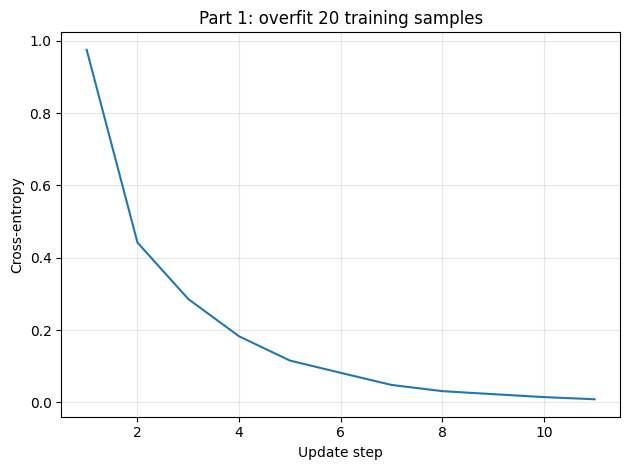

Overfit final: 0.008685924112796783 1.0 steps: 11
Part 1 checks complete; diagnostics and curve saved.


In [10]:
import importlib
import data as data_module, model as model_module, part1_checks
importlib.reload(data_module)
importlib.reload(model_module)
importlib.reload(part1_checks)
data, model, health = part1_checks.run_checks(REPO_ROOT, OUT_DIR, device)

MLP có đúng số tham số và shape yêu cầu. Gradient chảy tới toàn bộ tham số. Model học thuộc 20 mẫu với accuracy 100% và loss 0,00869 sau 11 bước, cho thấy mô hình và vòng cập nhật trọng số của phép kiểm tra hoạt động. Loss ban đầu trên validation là 2,2691, cao hơn mốc dự đoán đều ln(7).

# part 2


In [11]:
%%writefile optimizer.py
import torch

def build_optimizer(name, params, lr, weight_decay=0.0, momentum=0.9):
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, weight_decay=weight_decay)
    if name == "sgd_momentum":
        return torch.optim.SGD(
            params, lr=lr, momentum=momentum, weight_decay=weight_decay
        )
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")

def clip_gradients(params, max_norm=None):
    params = list(params)
    if max_norm is not None:
        # PyTorch trả về norm TRƯỚC khi clip.
        return float(torch.nn.utils.clip_grad_norm_(params, max_norm).item())

    norms = [p.grad.detach().float().norm(2)
             for p in params if p.grad is not None]
    if not norms:
        return 0.0
    return float(torch.stack(norms).norm(2).item())

Overwriting optimizer.py


In [12]:
%%writefile train.py
import random
import time
import numpy as np
import torch
import torch.nn.functional as F

from data import iterate_batches
from model import MLP, count_params, EXPECTED_PARAMS
from optimizer import build_optimizer, clip_gradients

DEFAULT_CFG = dict(
    exp_id="base-s1",
    group="baseline",
    description="M-base, SGD momentum",
    loss="ce",
    optimizer="sgd_momentum",
    lr=None,
    weight_decay=0.0,
    momentum=0.9,
    batch=512,
    epochs=20,
    hidden=(256, 128),
    dropout=0.0,
    init="he",
    clip_norm=None,
    precision="fp32",
    seed=1,
)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def compute_loss(logits, y, loss_name):
    if loss_name == "ce":
        return F.cross_entropy(logits, y)
    if loss_name == "mse":
        target = F.one_hot(y, num_classes=7).float()
        return F.mse_loss(logits.softmax(dim=1), target)
    raise ValueError(loss_name)

def macro_f1_from_confusion(cm):
    cm = np.asarray(cm, dtype=np.float64)
    tp = np.diag(cm)
    denominator = cm.sum(0) + cm.sum(1)
    f1 = np.divide(
        2 * tp, denominator,
        out=np.zeros_like(tp), where=denominator > 0
    )
    return float(f1.mean())

@torch.no_grad()
def evaluate(model, X, y, loss_name="ce", batch_size=8192):
    original_mode = model.training
    model.eval()
    loss_sum = 0.0
    cm = torch.zeros((7, 7), dtype=torch.int64, device=X.device)

    try:
        for start in range(0, len(y), batch_size):
            xb = X[start:start + batch_size]
            yb = y[start:start + batch_size]
            logits = model(xb)
            loss_sum += compute_loss(logits, yb, loss_name).item() * len(yb)
            pred = logits.argmax(1)
            cm += torch.bincount(
                yb * 7 + pred, minlength=49
            ).reshape(7, 7)

        cm_np = cm.cpu().numpy()
        return dict(
            loss=loss_sum / len(y),
            acc=float(np.trace(cm_np) / cm_np.sum()),
            macro_f1=macro_f1_from_confusion(cm_np),
        )
    finally:
        model.train(original_mode)

def run_experiment(cfg, data):
    cfg = {**DEFAULT_CFG, **cfg}
    if cfg["lr"] is None or cfg["lr"] <= 0:
        raise ValueError("Choose a positive learning rate")
    if cfg["precision"] != "fp32":
        raise ValueError("Part 2 currently supports fp32 only")

    set_seed(cfg["seed"])
    device = data["X_tr"].device
    model = MLP(
        hidden=tuple(cfg["hidden"]),
        dropout=cfg["dropout"],
        init=cfg["init"],
    ).to(device)
    assert count_params(model) == EXPECTED_PARAMS[tuple(cfg["hidden"])]

    optimizer = build_optimizer(
        cfg["optimizer"], model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        momentum=cfg["momentum"],
    )
    generator = torch.Generator(device=device)
    generator.manual_seed(cfg["seed"])

    is_cuda = device.type == "cuda"

    def synchronize():
        if is_cuda:
            torch.cuda.synchronize(device)

    if is_cuda:
        torch.cuda.reset_peak_memory_stats(device)

    synchronize()
    started = time.perf_counter()
    initial = evaluate(
        model, data["X_val"], data["y_val"], cfg["loss"]
    )
    history = []
    best_loss = float("inf")
    best_state = None
    best_metrics = None
    best_epoch = None
    diverged = False

    for epoch in range(1, cfg["epochs"] + 1):
        synchronize()
        epoch_started = time.perf_counter()
        model.train()
        gradient_norms = []

        for xb, yb in iterate_batches(
            data["X_tr"], data["y_tr"],
            cfg["batch"], generator=generator,
        ):
            optimizer.zero_grad(set_to_none=True)
            loss = compute_loss(model(xb), yb, cfg["loss"])

            if not torch.isfinite(loss).item():
                diverged = True
                break

            loss.backward()
            grad_norm = clip_gradients(
                model.parameters(), cfg["clip_norm"]
            )
            if not np.isfinite(grad_norm):
                diverged = True
                break

            gradient_norms.append(grad_norm)
            optimizer.step()

        if diverged:
            print(f"{cfg['exp_id']}: diverged at epoch {epoch}")
            break

        train_metrics = evaluate(
            model, data["X_tr"], data["y_tr"], cfg["loss"]
        )
        val_metrics = evaluate(
            model, data["X_val"], data["y_val"], cfg["loss"]
        )

        if not all(np.isfinite(m["loss"])
                   for m in (train_metrics, val_metrics)):
            diverged = True
            break

        synchronize()
        row = dict(
            epoch=epoch,
            train_loss=train_metrics["loss"],
            val_loss=val_metrics["loss"],
            val_acc=val_metrics["acc"],
            val_macro_f1=val_metrics["macro_f1"],
            grad_norm=float(np.mean(gradient_norms)),
            grad_norm_max=float(np.max(gradient_norms)),
            seconds=time.perf_counter() - epoch_started,
        )
        history.append(row)

        if val_metrics["loss"] < best_loss:
            best_loss = val_metrics["loss"]
            best_epoch = epoch
            best_metrics = dict(val_metrics)
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }

        print(
            f"{cfg['exp_id']} | {epoch:02d}/{cfg['epochs']} | "
            f"train={row['train_loss']:.4f} "
            f"val={row['val_loss']:.4f} "
            f"acc={row['val_acc']:.4f} "
            f"F1={row['val_macro_f1']:.4f} "
            f"grad={row['grad_norm']:.3f} "
            f"time={row['seconds']:.1f}s",
            flush=True,
        )

    synchronize()
    return dict(
        cfg=cfg,
        history=history,
        initial_val_loss=initial["loss"],
        best_epoch=best_epoch,
        best_val_loss=None if best_metrics is None else best_metrics["loss"],
        val_acc=None if best_metrics is None else best_metrics["acc"],
        val_macro_f1=None if best_metrics is None else best_metrics["macro_f1"],
        total_seconds=time.perf_counter() - started,
        peak_memory_mb=(
            torch.cuda.max_memory_allocated(device) / 1024**2
            if is_cuda else None
        ),
        diverged=diverged,
        best_state=best_state,
    )

Overwriting train.py


In [13]:
from pathlib import Path
import json
import importlib
import matplotlib.pyplot as plt

import optimizer as optimizer_module
import train as train_module

importlib.reload(optimizer_module)
importlib.reload(train_module)

DEFAULT_CFG = train_module.DEFAULT_CFG
run_experiment = train_module.run_experiment

OUT_DIR = Path(OUT_DIR)
(OUT_DIR / "results").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

def save_and_plot(result):
    exp_id = result["cfg"]["exp_id"]
    serializable = {
        key: value for key, value in result.items()
        if key != "best_state"
    }
    (OUT_DIR / "results" / f"{exp_id}.json").write_text(
        json.dumps(serializable, indent=2, allow_nan=False),
        encoding="utf-8",
    )

    history = result["history"]
    if not history:
        print(exp_id, "không hoàn thành epoch nào; đã lưu JSON.")
        return

    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, [r["train_loss"] for r in history], label="train")
    axes[0].plot(epochs, [r["val_loss"] for r in history], label="val")
    axes[0].set(ylabel="Loss")

    axes[1].plot(epochs, [r["val_acc"] for r in history], label="val accuracy")
    axes[1].plot(epochs, [r["val_macro_f1"] for r in history], label="val macro-F1")
    axes[1].set(ylabel="Score")

    axes[2].plot(epochs, [r["grad_norm"] for r in history], label="mean")
    axes[2].plot(epochs, [r["grad_norm_max"] for r in history], label="max")
    axes[2].set(ylabel="Gradient norm before clipping")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)
        ax.legend()

    cfg = result["cfg"]
    fig.suptitle(
        f"{exp_id}: {cfg['optimizer']}, lr={cfg['lr']}, "
        f"batch={cfg['batch']}, init={cfg['init']}"
    )
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / f"{exp_id}.png", dpi=150)
    plt.show()
    plt.close(fig)

# Dùng lại dict data từ Part 1.
assert isinstance(data, dict) and "X_tr" in data
all_results = {}

lr-search-0.01 | 01/5 | train=0.5765 val=0.5804 acc=0.7560 F1=0.4936 grad=0.437 time=1.4s
lr-search-0.01 | 02/5 | train=0.5251 val=0.5294 acc=0.7758 F1=0.5831 grad=0.505 time=1.2s
lr-search-0.01 | 03/5 | train=0.4897 val=0.4947 acc=0.7906 F1=0.5982 grad=0.603 time=1.3s
lr-search-0.01 | 04/5 | train=0.4672 val=0.4726 acc=0.8002 F1=0.6284 grad=0.705 time=1.3s
lr-search-0.01 | 05/5 | train=0.4445 val=0.4501 acc=0.8089 F1=0.6420 grad=0.798 time=1.3s


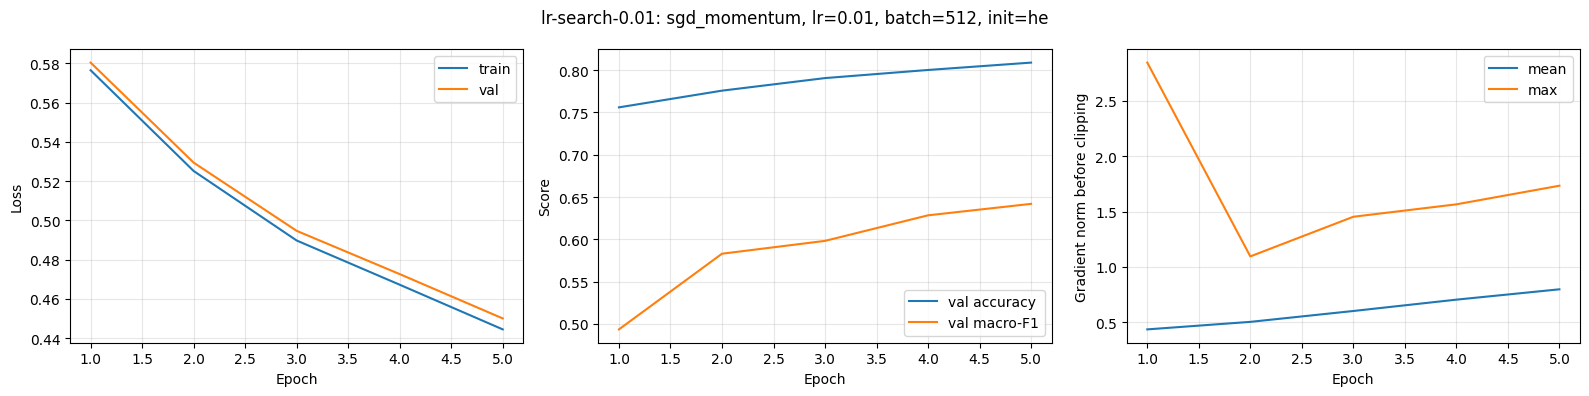

lr-search-0.03 | 01/5 | train=0.5141 val=0.5170 acc=0.7801 F1=0.5788 grad=0.518 time=1.3s
lr-search-0.03 | 02/5 | train=0.4523 val=0.4572 acc=0.8069 F1=0.6547 grad=0.729 time=1.3s
lr-search-0.03 | 03/5 | train=0.4175 val=0.4229 acc=0.8242 F1=0.6864 grad=0.803 time=1.2s
lr-search-0.03 | 04/5 | train=0.4050 val=0.4123 acc=0.8291 F1=0.7080 grad=0.897 time=1.2s
lr-search-0.03 | 05/5 | train=0.3668 val=0.3735 acc=0.8447 F1=0.7279 grad=0.894 time=1.3s


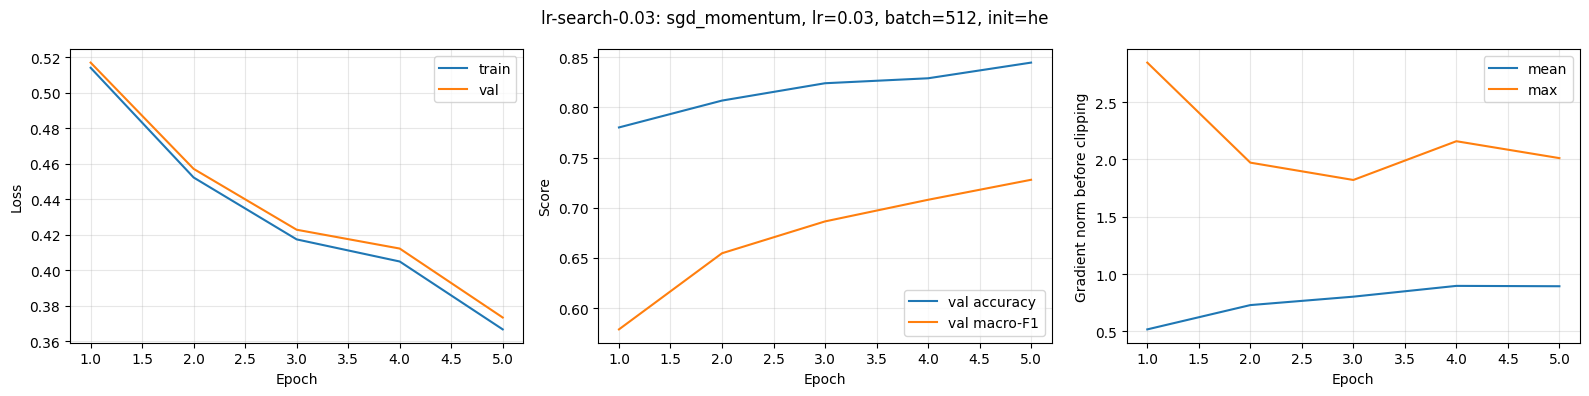

lr-search-0.1 | 01/5 | train=0.4585 val=0.4634 acc=0.8012 F1=0.6236 grad=0.529 time=1.2s
lr-search-0.1 | 02/5 | train=0.3927 val=0.3980 acc=0.8313 F1=0.7018 grad=0.568 time=1.3s
lr-search-0.1 | 03/5 | train=0.3736 val=0.3813 acc=0.8383 F1=0.7237 grad=0.569 time=1.4s
lr-search-0.1 | 04/5 | train=0.3663 val=0.3761 acc=0.8449 F1=0.7393 grad=0.575 time=1.3s
lr-search-0.1 | 05/5 | train=0.3141 val=0.3228 acc=0.8669 F1=0.7756 grad=0.572 time=1.3s


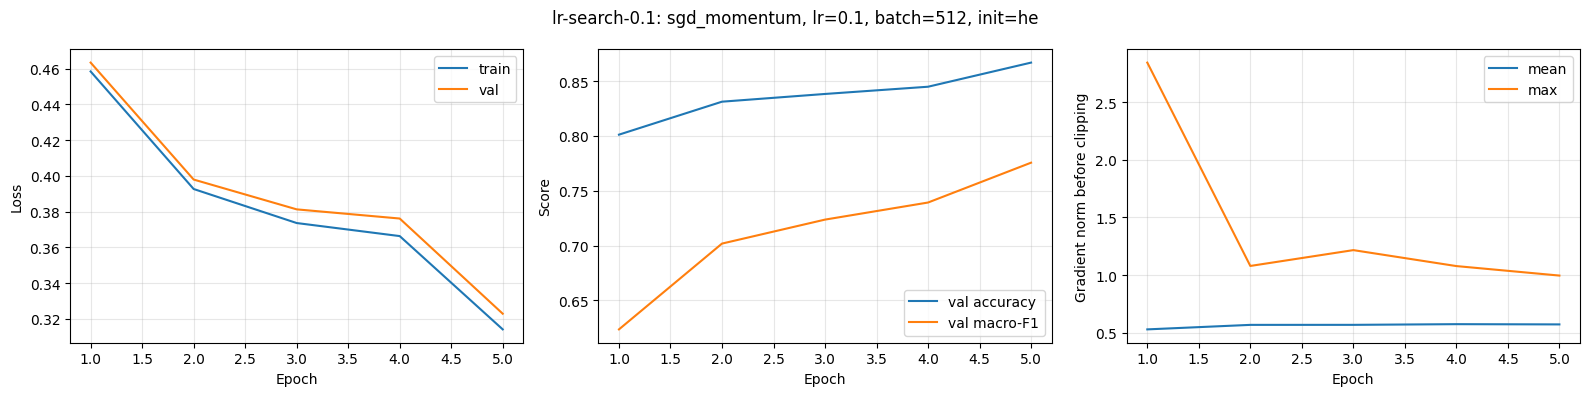

,exp_id,lr,best_epoch,val_loss,val_acc,val_macro_f1,diverged
0,lr-search-0.01,0.01,5,0.450051,0.808933,0.641976,False
1,lr-search-0.03,0.03,5,0.373498,0.844732,0.727929,False
2,lr-search-0.1,0.10,5,0.322842,0.866924,0.775632,False


Learning rate chọn bằng validation: 0.1


In [14]:
import pandas as pd

lr_results = []

for lr in [0.01, 0.03, 0.1]:
    cfg = {
        **DEFAULT_CFG,
        "exp_id": f"lr-search-{lr:g}",
        "group": "lr_search",
        "description": "5-epoch pilot for baseline learning rate",
        "lr": lr,
        "epochs": 5,
        "seed": 1,
    }
    result = run_experiment(cfg, data)
    save_and_plot(result)
    all_results[cfg["exp_id"]] = result
    lr_results.append(result)

eligible = [
    r for r in lr_results
    if not r["diverged"] and r["val_macro_f1"] is not None
]
if not eligible:
    raise RuntimeError("Mọi learning rate đều thất bại; cần kiểm tra log.")

winner = max(eligible, key=lambda r: r["val_macro_f1"])
baseline_lr = winner["cfg"]["lr"]

display(pd.DataFrame([
    {
        "exp_id": r["cfg"]["exp_id"],
        "lr": r["cfg"]["lr"],
        "best_epoch": r["best_epoch"],
        "val_loss": r["best_val_loss"],
        "val_acc": r["val_acc"],
        "val_macro_f1": r["val_macro_f1"],
        "diverged": r["diverged"],
    }
    for r in lr_results
]))

print("Learning rate chọn bằng validation:", baseline_lr)

base-s1 | 01/20 | train=0.4585 val=0.4634 acc=0.8012 F1=0.6236 grad=0.529 time=1.3s
base-s1 | 02/20 | train=0.3927 val=0.3980 acc=0.8313 F1=0.7018 grad=0.568 time=1.3s
base-s1 | 03/20 | train=0.3736 val=0.3813 acc=0.8383 F1=0.7237 grad=0.569 time=1.3s
base-s1 | 04/20 | train=0.3663 val=0.3761 acc=0.8449 F1=0.7393 grad=0.575 time=1.3s
base-s1 | 05/20 | train=0.3141 val=0.3228 acc=0.8669 F1=0.7756 grad=0.572 time=1.2s
base-s1 | 06/20 | train=0.3053 val=0.3165 acc=0.8712 F1=0.7925 grad=0.586 time=1.3s
base-s1 | 07/20 | train=0.2970 val=0.3083 acc=0.8726 F1=0.7945 grad=0.574 time=1.3s
base-s1 | 08/20 | train=0.2775 val=0.2904 acc=0.8800 F1=0.8003 grad=0.571 time=1.3s
base-s1 | 09/20 | train=0.2826 val=0.2986 acc=0.8806 F1=0.8101 grad=0.571 time=1.3s
base-s1 | 10/20 | train=0.2692 val=0.2849 acc=0.8850 F1=0.8086 grad=0.572 time=1.2s
base-s1 | 11/20 | train=0.2473 val=0.2622 acc=0.8924 F1=0.8297 grad=0.556 time=1.3s
base-s1 | 12/20 | train=0.2477 val=0.2644 acc=0.8922 F1=0.8381 grad=0.563 ti

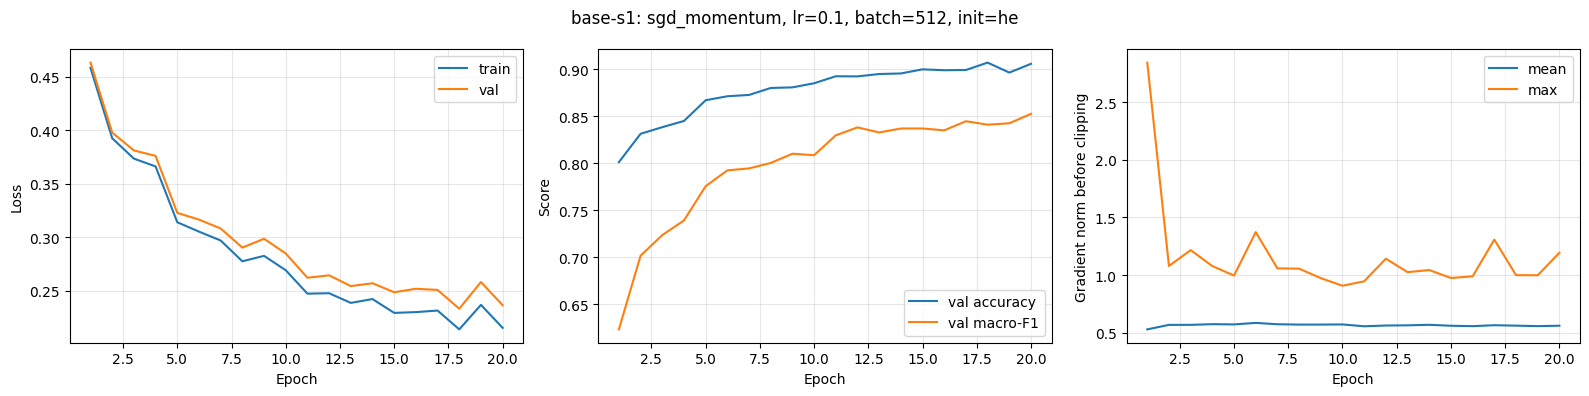

base-s2 | 01/20 | train=0.4859 val=0.4929 acc=0.7888 F1=0.6655 grad=0.511 time=1.2s
base-s2 | 02/20 | train=0.3862 val=0.3917 acc=0.8392 F1=0.7254 grad=0.542 time=1.3s
base-s2 | 03/20 | train=0.3702 val=0.3790 acc=0.8425 F1=0.7439 grad=0.567 time=1.3s
base-s2 | 04/20 | train=0.3260 val=0.3350 acc=0.8622 F1=0.7640 grad=0.564 time=1.2s
base-s2 | 05/20 | train=0.3173 val=0.3267 acc=0.8657 F1=0.7724 grad=0.580 time=1.3s
base-s2 | 06/20 | train=0.3100 val=0.3207 acc=0.8702 F1=0.7829 grad=0.565 time=1.2s
base-s2 | 07/20 | train=0.2840 val=0.2968 acc=0.8800 F1=0.8013 grad=0.582 time=1.3s
base-s2 | 08/20 | train=0.2867 val=0.3002 acc=0.8754 F1=0.7986 grad=0.562 time=1.3s
base-s2 | 09/20 | train=0.2609 val=0.2757 acc=0.8886 F1=0.8211 grad=0.566 time=1.3s
base-s2 | 10/20 | train=0.2658 val=0.2819 acc=0.8852 F1=0.8142 grad=0.558 time=1.3s
base-s2 | 11/20 | train=0.2435 val=0.2584 acc=0.8954 F1=0.8331 grad=0.566 time=1.3s
base-s2 | 12/20 | train=0.2319 val=0.2471 acc=0.9014 F1=0.8398 grad=0.560 ti

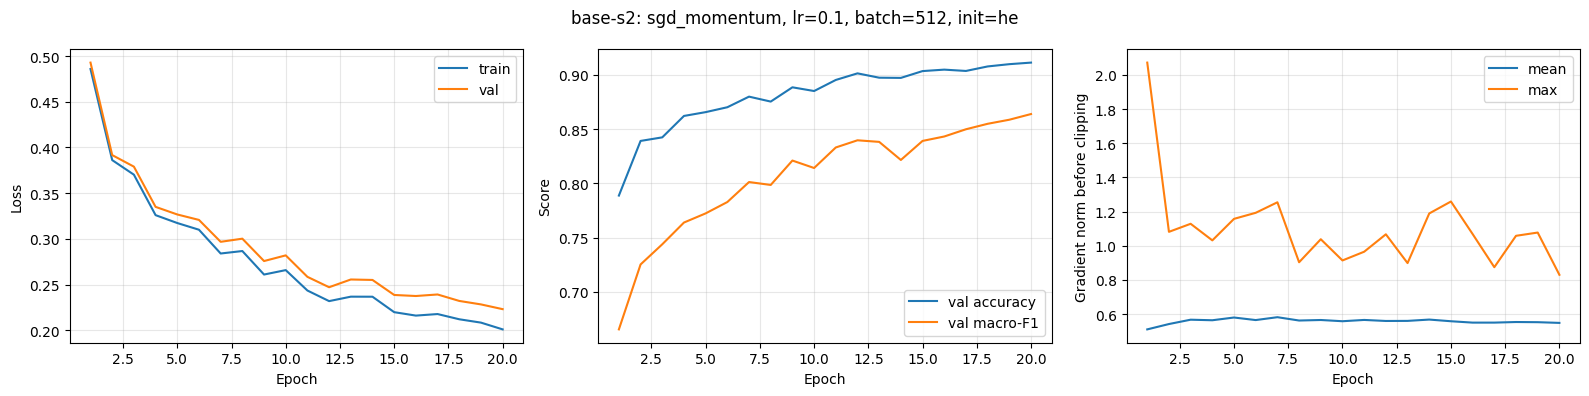

base-s3 | 01/20 | train=0.4795 val=0.4831 acc=0.7928 F1=0.5755 grad=0.539 time=1.3s
base-s3 | 02/20 | train=0.3882 val=0.3928 acc=0.8339 F1=0.6894 grad=0.561 time=1.3s
base-s3 | 03/20 | train=0.3589 val=0.3629 acc=0.8497 F1=0.7401 grad=0.595 time=1.2s
base-s3 | 04/20 | train=0.3287 val=0.3383 acc=0.8594 F1=0.7588 grad=0.586 time=1.3s
base-s3 | 05/20 | train=0.3141 val=0.3239 acc=0.8654 F1=0.7821 grad=0.582 time=1.3s
base-s3 | 06/20 | train=0.2902 val=0.3003 acc=0.8766 F1=0.8058 grad=0.591 time=1.3s
base-s3 | 07/20 | train=0.2881 val=0.2989 acc=0.8776 F1=0.7962 grad=0.586 time=1.3s
base-s3 | 08/20 | train=0.2573 val=0.2692 acc=0.8903 F1=0.8221 grad=0.585 time=1.3s
base-s3 | 09/20 | train=0.2685 val=0.2827 acc=0.8841 F1=0.8196 grad=0.582 time=1.3s
base-s3 | 10/20 | train=0.2479 val=0.2626 acc=0.8936 F1=0.8269 grad=0.575 time=1.3s
base-s3 | 11/20 | train=0.2452 val=0.2639 acc=0.8930 F1=0.8313 grad=0.578 time=1.2s
base-s3 | 12/20 | train=0.2542 val=0.2704 acc=0.8908 F1=0.8421 grad=0.586 ti

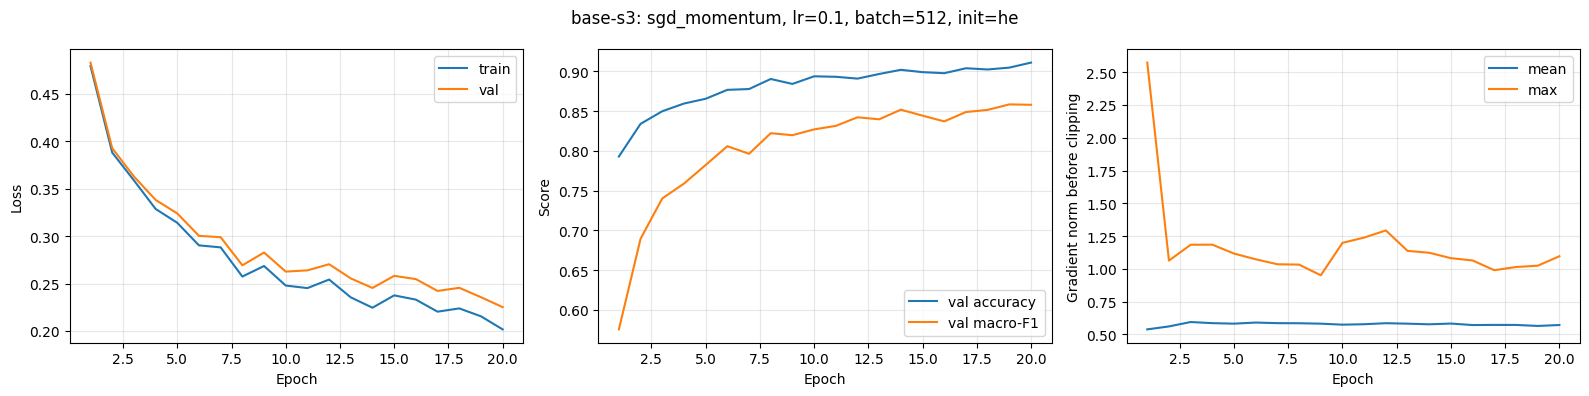

,exp_id,seed,best_epoch,val_loss,val_acc,val_macro_f1,seconds
0,base-s1,1,18,0.233159,0.906897,0.840989,25.528629
1,base-s2,2,20,0.223070,0.911340,0.863947,25.748715
2,base-s3,3,20,0.225100,0.910878,0.857861,25.717978


Val accuracy: 0.9097 ± 0.0024
Val macro-F1: 0.8543 ± 0.0119
Ngưỡng tham khảo 2σ macro-F1: 0.0238


275

In [15]:
baseline_results = []

for seed in [1, 2, 3]:
    cfg = {
        **DEFAULT_CFG,
        "exp_id": f"base-s{seed}",
        "lr": baseline_lr,
        "epochs": 20,
        "seed": seed,
    }
    result = run_experiment(cfg, data)
    save_and_plot(result)
    all_results[cfg["exp_id"]] = result
    baseline_results.append(result)

if any(r["diverged"] for r in baseline_results):
    raise RuntimeError("Có baseline phân kỳ; kiểm tra log trước khi so sánh.")

scores = pd.DataFrame([
    {
        "exp_id": r["cfg"]["exp_id"],
        "seed": r["cfg"]["seed"],
        "best_epoch": r["best_epoch"],
        "val_loss": r["best_val_loss"],
        "val_acc": r["val_acc"],
        "val_macro_f1": r["val_macro_f1"],
        "seconds": r["total_seconds"],
    }
    for r in baseline_results
])

display(scores)

acc_mean = scores["val_acc"].mean()
acc_std = scores["val_acc"].std(ddof=1)
f1_mean = scores["val_macro_f1"].mean()
f1_std = scores["val_macro_f1"].std(ddof=1)

print(f"Val accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Val macro-F1: {f1_mean:.4f} ± {f1_std:.4f}")
print(f"Ngưỡng tham khảo 2σ macro-F1: {2*f1_std:.4f}")

seed_summary = {
    "baseline_lr": baseline_lr,
    "seeds": [1, 2, 3],
    "val_acc_mean": float(acc_mean),
    "val_acc_std": float(acc_std),
    "val_macro_f1_mean": float(f1_mean),
    "val_macro_f1_std": float(f1_std),
    "noise_reference_2sigma": float(2*f1_std),
}
(OUT_DIR / "results" / "baseline_seed_summary.json").write_text(
    json.dumps(seed_summary, indent=2), encoding="utf-8"
)

# Part 3


In [16]:
%%writefile train_part3.py
import time
import numpy as np
import torch

from model import MLP, count_params, EXPECTED_PARAMS
from data import iterate_batches
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, compute_loss, evaluate

def run_experiment(cfg, data):
    cfg = {**DEFAULT_CFG, **cfg}
    if cfg["lr"] is None or cfg["lr"] <= 0:
        raise ValueError("Learning rate must be positive")

    device = data["X_tr"].device
    is_cuda = device.type == "cuda"
    precision = cfg["precision"]

    if precision not in {"fp32", "fp16", "bf16"}:
        raise ValueError(precision)
    if precision != "fp32" and not is_cuda:
        raise ValueError("Mixed precision experiments require CUDA")
    if precision == "bf16" and not torch.cuda.is_bf16_supported():
        raise ValueError("GPU này không hỗ trợ BF16 native")

    amp_enabled = precision != "fp32"
    amp_dtype = torch.bfloat16 if precision == "bf16" else torch.float16
    scaler = torch.amp.GradScaler(
        "cuda", enabled=(precision == "fp16")
    )

    def synchronize():
        if is_cuda:
            torch.cuda.synchronize(device)

    set_seed(cfg["seed"])
    model = MLP(
        hidden=tuple(cfg["hidden"]),
        dropout=cfg["dropout"],
        init=cfg["init"],
    ).to(device)
    assert count_params(model) == EXPECTED_PARAMS[tuple(cfg["hidden"])]

    optimizer = build_optimizer(
        cfg["optimizer"], model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        momentum=cfg["momentum"],
    )
    generator = torch.Generator(device=device)
    generator.manual_seed(cfg["seed"])

    synchronize()
    if is_cuda:
        torch.cuda.reset_peak_memory_stats(device)
    started = time.perf_counter()

    initial = evaluate(
        model, data["X_val"], data["y_val"], cfg["loss"]
    )
    history = []
    best_loss = float("inf")
    best_state = None
    best_metrics = None
    best_epoch = None
    diverged = False

    for epoch in range(1, cfg["epochs"] + 1):
        synchronize()
        epoch_started = time.perf_counter()
        model.train()
        gradient_norms = []
        clipped_steps = 0
        skipped_steps = 0
        attempted_steps = 0

        for xb, yb in iterate_batches(
            data["X_tr"], data["y_tr"],
            cfg["batch"], generator=generator,
        ):
            attempted_steps += 1
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                dtype=amp_dtype,
                enabled=amp_enabled,
            ):
                logits = model(xb)
                # Tính loss bằng FP32 để ổn định số học.
                loss = compute_loss(logits.float(), yb, cfg["loss"])

            if not torch.isfinite(loss).item():
                diverged = True
                break

            scaler.scale(loss).backward()
            # Gradient phải được unscale trước khi đo hoặc clip.
            scaler.unscale_(optimizer)

            grad_norm = clip_gradients(
                model.parameters(), cfg["clip_norm"]
            )

            if not np.isfinite(grad_norm):
                if precision == "fp16":
                    # GradScaler bỏ cập nhật khi gradient overflow.
                    scaler.step(optimizer)
                    scaler.update()
                    skipped_steps += 1
                    continue

                diverged = True
                break

            gradient_norms.append(grad_norm)
            if (cfg["clip_norm"] is not None
                    and grad_norm > cfg["clip_norm"]):
                clipped_steps += 1

            scaler.step(optimizer)
            scaler.update()

        synchronize()
        train_seconds = time.perf_counter() - epoch_started

        if diverged:
            print(f"{cfg['exp_id']}: diverged at epoch {epoch}")
            break
        if not gradient_norms:
            diverged = True
            print(f"{cfg['exp_id']}: no finite gradient updates")
            break

        train_metrics = evaluate(
            model, data["X_tr"], data["y_tr"], cfg["loss"]
        )
        val_metrics = evaluate(
            model, data["X_val"], data["y_val"], cfg["loss"]
        )

        if not all(np.isfinite(m["loss"])
                   for m in (train_metrics, val_metrics)):
            diverged = True
            break

        synchronize()
        row = dict(
            epoch=epoch,
            train_loss=train_metrics["loss"],
            val_loss=val_metrics["loss"],
            val_acc=val_metrics["acc"],
            val_macro_f1=val_metrics["macro_f1"],
            grad_norm=float(np.mean(gradient_norms)),
            grad_norm_max=float(np.max(gradient_norms)),
            clip_fraction=clipped_steps / len(gradient_norms),
            skipped_steps=skipped_steps,
            attempted_steps=attempted_steps,
            train_seconds=train_seconds,
            seconds=time.perf_counter() - epoch_started,
        )
        history.append(row)

        if val_metrics["loss"] < best_loss:
            best_loss = val_metrics["loss"]
            best_epoch = epoch
            best_metrics = dict(val_metrics)
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }

        print(
            f"{cfg['exp_id']} | {epoch:02d}/{cfg['epochs']} | "
            f"train={row['train_loss']:.4f} "
            f"val={row['val_loss']:.4f} "
            f"acc={row['val_acc']:.4f} "
            f"F1={row['val_macro_f1']:.4f} "
            f"clip={row['clip_fraction']:.1%} "
            f"skip={skipped_steps} "
            f"time={row['seconds']:.1f}s",
            flush=True,
        )

    synchronize()
    return dict(
        cfg=cfg,
        history=history,
        initial_val_loss=initial["loss"],
        best_epoch=best_epoch,
        best_val_loss=None if best_metrics is None else best_metrics["loss"],
        val_acc=None if best_metrics is None else best_metrics["acc"],
        val_macro_f1=None if best_metrics is None else best_metrics["macro_f1"],
        total_seconds=time.perf_counter() - started,
        peak_memory_mb=(
            torch.cuda.max_memory_allocated(device) / 1024**2
            if is_cuda else None
        ),
        diverged=diverged,
        best_state=best_state,
    )

Writing train_part3.py


In [17]:
import importlib
import numpy as np
import pandas as pd
import torch

import train_part3
importlib.reload(train_part3)
run_experiment = train_part3.run_experiment

base = all_results["base-s1"]
assert not base["diverged"]
assert len(base["history"]) == 20

base_cfg = {
    **base["cfg"],
    "seed": 1,
    "epochs": 20,
}

part3_results = []
noise_reference = 2 * float(f1_std)

def run_part3(exp_id, group, prediction, **changes):
    print("\n" + "=" * 65)
    print("Thí nghiệm:", exp_id)
    print("Dự đoán:", prediction)

    cfg = {
        **base_cfg,
        **changes,
        "exp_id": exp_id,
        "group": group,
        "description": prediction,
    }
    result = run_experiment(cfg, data)
    save_and_plot(result)

    all_results[exp_id] = result
    part3_results.append(result)

    if result["diverged"]:
        print("Kết quả: phân kỳ; không dùng để chọn cấu hình cuối.")
    else:
        delta = result["val_macro_f1"] - base["val_macro_f1"]
        print(f"Val macro-F1: {result['val_macro_f1']:.4f}")
        print(f"Chênh lệch với base-s1: {delta:+.4f}")
        print(f"Mốc nhiễu baseline 2σ: {noise_reference:.4f}")
        print("Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ")
        print("để khẳng định khác biệt chắc chắn.")

    return result


Thí nghiệm: loss-mse
Dự đoán: MSE có thể học chậm hơn CE với cùng learning rate và số epoch.
loss-mse | 01/20 | train=0.0549 val=0.0550 acc=0.7381 F1=0.3363 clip=0.0% skip=0 time=1.4s
loss-mse | 02/20 | train=0.0505 val=0.0508 acc=0.7597 F1=0.4108 clip=0.0% skip=0 time=1.4s
loss-mse | 03/20 | train=0.0431 val=0.0436 acc=0.7919 F1=0.5455 clip=0.0% skip=0 time=1.4s
loss-mse | 04/20 | train=0.0410 val=0.0416 acc=0.8029 F1=0.6062 clip=0.0% skip=0 time=1.4s
loss-mse | 05/20 | train=0.0390 val=0.0395 acc=0.8129 F1=0.6168 clip=0.0% skip=0 time=1.5s
loss-mse | 06/20 | train=0.0371 val=0.0377 acc=0.8224 F1=0.6328 clip=0.0% skip=0 time=1.4s
loss-mse | 07/20 | train=0.0359 val=0.0366 acc=0.8267 F1=0.6516 clip=0.0% skip=0 time=1.4s
loss-mse | 08/20 | train=0.0347 val=0.0355 acc=0.8323 F1=0.6629 clip=0.0% skip=0 time=1.4s
loss-mse | 09/20 | train=0.0339 val=0.0347 acc=0.8364 F1=0.6574 clip=0.0% skip=0 time=1.4s
loss-mse | 10/20 | train=0.0323 val=0.0331 acc=0.8452 F1=0.6899 clip=0.0% skip=0 time=1

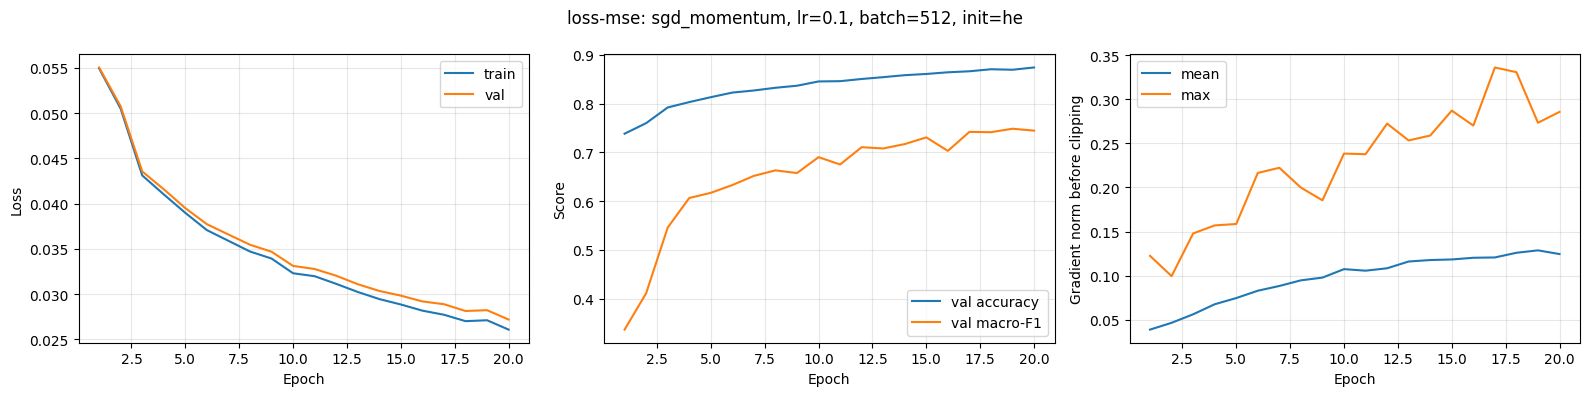

Val macro-F1: 0.7443
Chênh lệch với base-s1: -0.0966
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.


In [18]:
mse_result = run_part3(
    "loss-mse",
    "loss",
    "MSE có thể học chậm hơn CE với cùng learning rate và số epoch.",
    loss="mse",
)


Thí nghiệm: opt-adam-lr1e-3
Dự đoán: Adam lr=0.001 có thể hội tụ nhanh hơn SGD momentum; đây là so sánh cấu hình, chưa phải so sánh optimizer đã tune công bằng.
opt-adam-lr1e-3 | 01/20 | train=0.4907 val=0.4949 acc=0.7884 F1=0.5963 clip=0.0% skip=0 time=1.5s
opt-adam-lr1e-3 | 02/20 | train=0.4161 val=0.4219 acc=0.8206 F1=0.6877 clip=0.0% skip=0 time=1.4s
opt-adam-lr1e-3 | 03/20 | train=0.3884 val=0.3956 acc=0.8340 F1=0.7194 clip=0.0% skip=0 time=1.4s
opt-adam-lr1e-3 | 04/20 | train=0.3484 val=0.3570 acc=0.8524 F1=0.7483 clip=0.0% skip=0 time=1.5s
opt-adam-lr1e-3 | 05/20 | train=0.3316 val=0.3411 acc=0.8590 F1=0.7634 clip=0.0% skip=0 time=1.4s
opt-adam-lr1e-3 | 06/20 | train=0.3130 val=0.3236 acc=0.8684 F1=0.7900 clip=0.0% skip=0 time=1.4s
opt-adam-lr1e-3 | 07/20 | train=0.3025 val=0.3138 acc=0.8713 F1=0.7980 clip=0.0% skip=0 time=1.5s
opt-adam-lr1e-3 | 08/20 | train=0.2937 val=0.3053 acc=0.8753 F1=0.7885 clip=0.0% skip=0 time=1.5s
opt-adam-lr1e-3 | 09/20 | train=0.2767 val=0.2896 acc=

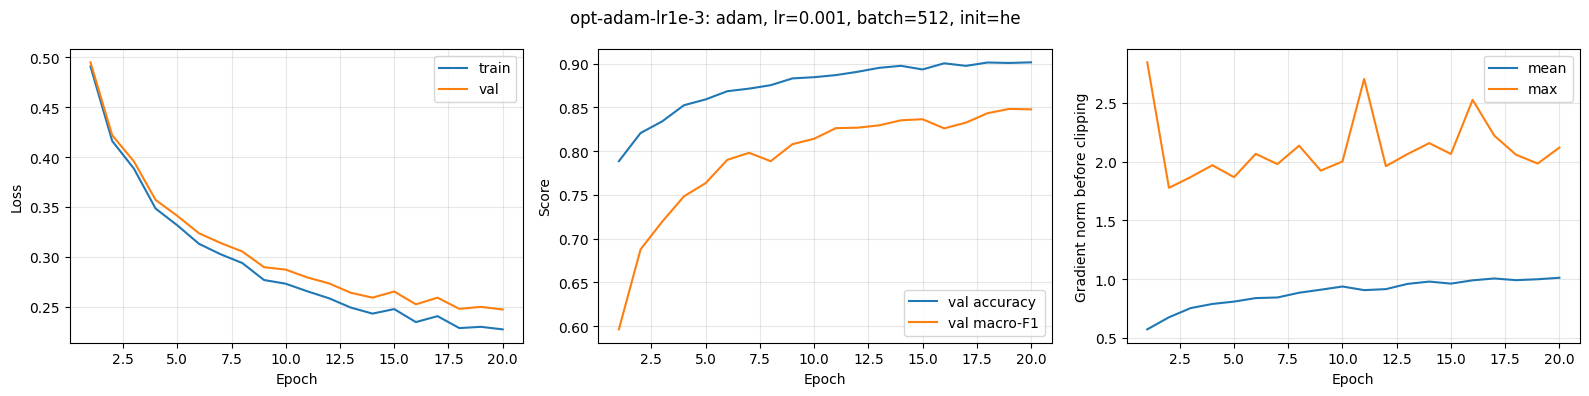

Val macro-F1: 0.8476
Chênh lệch với base-s1: +0.0067
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.


In [19]:
adam_result = run_part3(
    "opt-adam-lr1e-3",
    "optimizer",
    "Adam lr=0.001 có thể hội tụ nhanh hơn SGD momentum; "
    "đây là so sánh cấu hình, chưa phải so sánh optimizer đã tune công bằng.",
    optimizer="adam",
    lr=0.001,
)


Thí nghiệm: hparam-batch1024
Dự đoán: Batch 1024 có thể giảm thời gian mỗi epoch, nhưng ít bước cập nhật hơn có thể làm điểm validation thấp hơn.
hparam-batch1024 | 01/20 | train=0.4918 val=0.4948 acc=0.7893 F1=0.6063 clip=0.0% skip=0 time=0.7s
hparam-batch1024 | 02/20 | train=0.4304 val=0.4363 acc=0.8155 F1=0.6605 clip=0.0% skip=0 time=0.7s
hparam-batch1024 | 03/20 | train=0.4222 val=0.4290 acc=0.8195 F1=0.6765 clip=0.0% skip=0 time=0.7s
hparam-batch1024 | 04/20 | train=0.4591 val=0.4679 acc=0.7998 F1=0.6930 clip=0.0% skip=0 time=0.7s
hparam-batch1024 | 05/20 | train=0.3467 val=0.3542 acc=0.8547 F1=0.7543 clip=0.0% skip=0 time=0.7s
hparam-batch1024 | 06/20 | train=0.3341 val=0.3444 acc=0.8584 F1=0.7597 clip=0.0% skip=0 time=0.7s
hparam-batch1024 | 07/20 | train=0.3612 val=0.3711 acc=0.8412 F1=0.7651 clip=0.0% skip=0 time=0.7s
hparam-batch1024 | 08/20 | train=0.3072 val=0.3175 acc=0.8694 F1=0.7650 clip=0.0% skip=0 time=0.7s
hparam-batch1024 | 09/20 | train=0.2879 val=0.2992 acc=0.8767

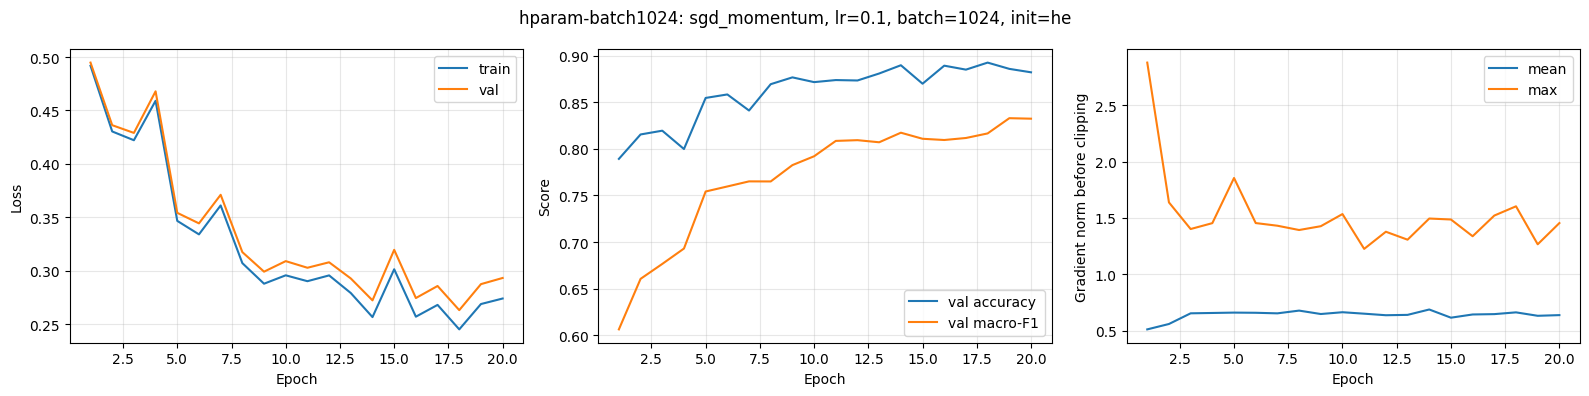

Val macro-F1: 0.8166
Chênh lệch với base-s1: -0.0244
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.


In [20]:
batch_result = run_part3(
    "hparam-batch1024",
    "hparam",
    "Batch 1024 có thể giảm thời gian mỗi epoch, nhưng ít bước cập nhật "
    "hơn có thể làm điểm validation thấp hơn.",
    batch=1024,
)


Thí nghiệm: dropout-p02
Dự đoán: Dropout 0.2 có thể giảm quá khớp; nếu baseline chưa quá khớp thì có thể làm việc học chậm hơn.
dropout-p02 | 01/20 | train=0.5197 val=0.5226 acc=0.7720 F1=0.5469 clip=0.0% skip=0 time=1.4s
dropout-p02 | 02/20 | train=0.4508 val=0.4541 acc=0.8071 F1=0.6580 clip=0.0% skip=0 time=1.4s
dropout-p02 | 03/20 | train=0.4160 val=0.4196 acc=0.8229 F1=0.6914 clip=0.0% skip=0 time=1.5s
dropout-p02 | 04/20 | train=0.3924 val=0.3971 acc=0.8331 F1=0.7009 clip=0.0% skip=0 time=1.5s
dropout-p02 | 05/20 | train=0.3691 val=0.3743 acc=0.8453 F1=0.7238 clip=0.0% skip=0 time=1.5s
dropout-p02 | 06/20 | train=0.3606 val=0.3658 acc=0.8490 F1=0.7380 clip=0.0% skip=0 time=1.4s
dropout-p02 | 07/20 | train=0.3477 val=0.3532 acc=0.8538 F1=0.7515 clip=0.0% skip=0 time=1.5s
dropout-p02 | 08/20 | train=0.3393 val=0.3452 acc=0.8584 F1=0.7656 clip=0.0% skip=0 time=1.4s
dropout-p02 | 09/20 | train=0.3277 val=0.3332 acc=0.8625 F1=0.7671 clip=0.0% skip=0 time=1.4s
dropout-p02 | 10/20 | tra

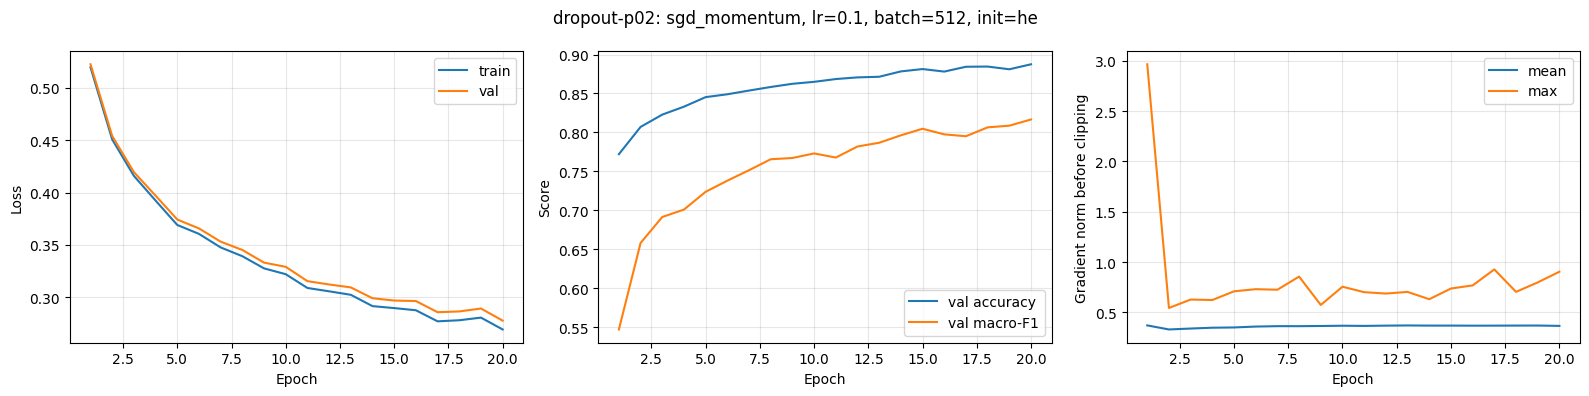

Val macro-F1: 0.8166
Chênh lệch với base-s1: -0.0244
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.


In [21]:
dropout_result = run_part3(
    "dropout-p02",
    "dropout",
    "Dropout 0.2 có thể giảm quá khớp; nếu baseline chưa quá khớp "
    "thì có thể làm việc học chậm hơn.",
    dropout=0.2,
)

Ngưỡng clipping: 0.283430797228541

Thí nghiệm: clip-normal-lr
Dự đoán: Clipping có thể không giúp ở learning rate ổn định; ngưỡng thấp cũng có thể làm học chậm.
clip-normal-lr | 01/20 | train=0.4743 val=0.4781 acc=0.7967 F1=0.6111 clip=99.7% skip=0 time=1.4s
clip-normal-lr | 02/20 | train=0.4123 val=0.4181 acc=0.8244 F1=0.6863 clip=100.0% skip=0 time=1.4s
clip-normal-lr | 03/20 | train=0.3852 val=0.3918 acc=0.8372 F1=0.7174 clip=100.0% skip=0 time=1.3s
clip-normal-lr | 04/20 | train=0.3751 val=0.3842 acc=0.8441 F1=0.7309 clip=100.0% skip=0 time=1.4s
clip-normal-lr | 05/20 | train=0.3548 val=0.3639 acc=0.8477 F1=0.7477 clip=100.0% skip=0 time=1.4s
clip-normal-lr | 06/20 | train=0.3213 val=0.3312 acc=0.8626 F1=0.7639 clip=100.0% skip=0 time=1.3s
clip-normal-lr | 07/20 | train=0.3242 val=0.3342 acc=0.8611 F1=0.7670 clip=100.0% skip=0 time=1.4s
clip-normal-lr | 08/20 | train=0.3136 val=0.3260 acc=0.8642 F1=0.7562 clip=100.0% skip=0 time=1.4s
clip-normal-lr | 09/20 | train=0.3138 val=0.326

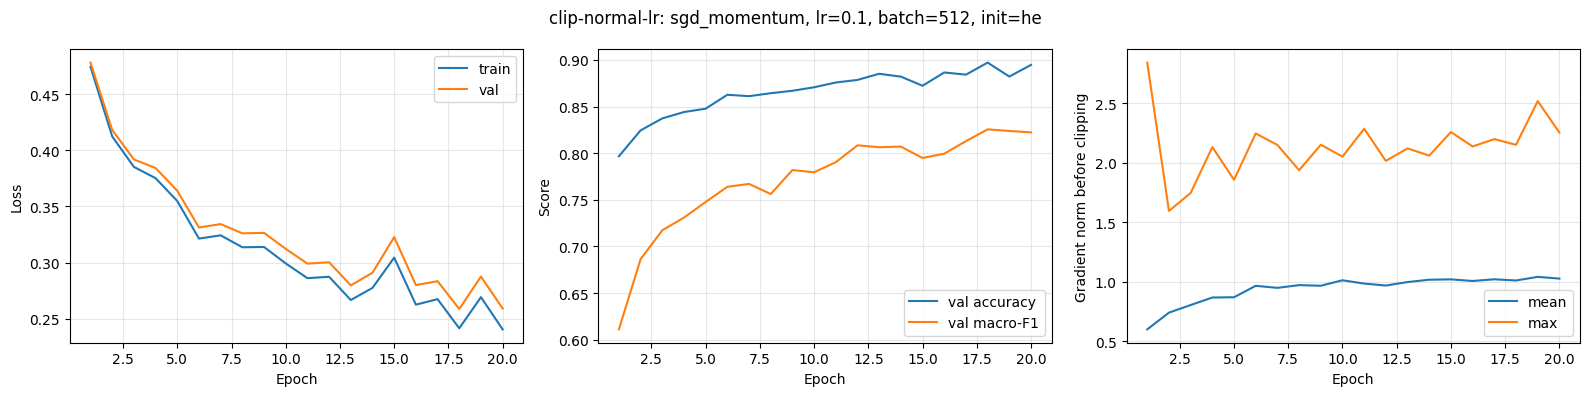

Val macro-F1: 0.8255
Chênh lệch với base-s1: -0.0155
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.


In [22]:
baseline_norms = np.array([
    row["grad_norm"] for row in base["history"]
])
clip_threshold = max(1e-6, float(np.median(baseline_norms) * 0.5))

print("Ngưỡng clipping:", clip_threshold)

clip_result = run_part3(
    "clip-normal-lr",
    "clipping",
    "Clipping có thể không giúp ở learning rate ổn định; "
    "ngưỡng thấp cũng có thể làm học chậm.",
    clip_norm=clip_threshold,
)


Thí nghiệm: highlr-no-clip
Dự đoán: Learning rate gấp 5 baseline có thể gây dao động hoặc phân kỳ.
highlr-no-clip | 01/20 | train=0.4630 val=0.4677 acc=0.8030 F1=0.5894 clip=0.0% skip=0 time=1.3s
highlr-no-clip | 02/20 | train=0.3981 val=0.4047 acc=0.8312 F1=0.7010 clip=0.0% skip=0 time=1.3s
highlr-no-clip | 03/20 | train=0.3653 val=0.3759 acc=0.8435 F1=0.7272 clip=0.0% skip=0 time=1.3s
highlr-no-clip | 04/20 | train=0.3294 val=0.3400 acc=0.8625 F1=0.7566 clip=0.0% skip=0 time=1.3s
highlr-no-clip | 05/20 | train=0.3117 val=0.3245 acc=0.8691 F1=0.7843 clip=0.0% skip=0 time=1.3s
highlr-no-clip | 06/20 | train=0.2946 val=0.3071 acc=0.8733 F1=0.7915 clip=0.0% skip=0 time=1.3s
highlr-no-clip | 07/20 | train=0.2837 val=0.2966 acc=0.8784 F1=0.7897 clip=0.0% skip=0 time=1.3s
highlr-no-clip | 08/20 | train=0.2780 val=0.2950 acc=0.8814 F1=0.8031 clip=0.0% skip=0 time=1.2s
highlr-no-clip | 09/20 | train=0.2802 val=0.2952 acc=0.8824 F1=0.7721 clip=0.0% skip=0 time=1.3s
highlr-no-clip | 10/20 | tr

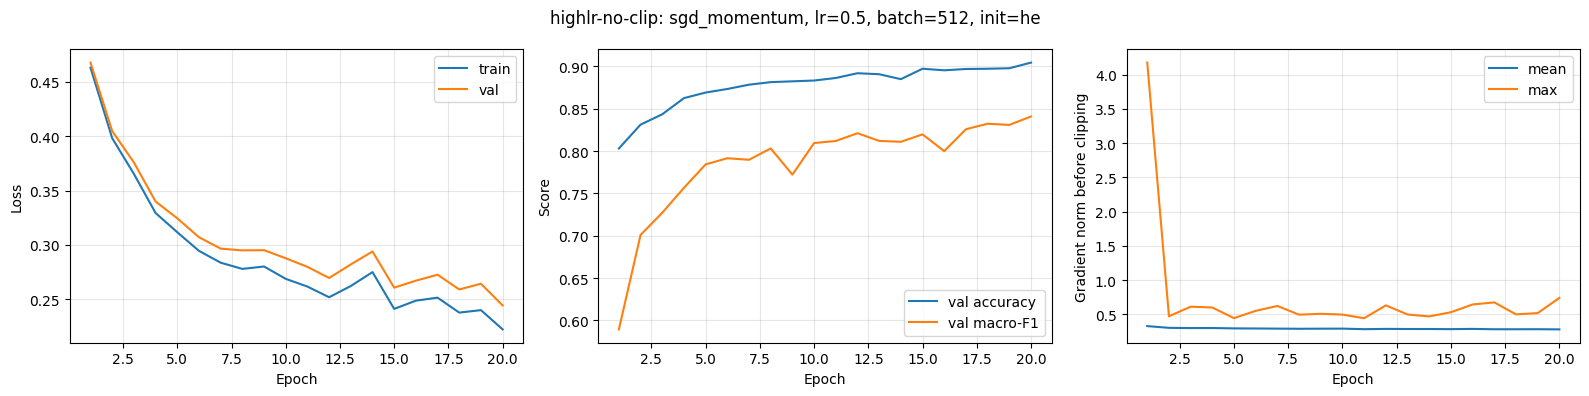

Val macro-F1: 0.8408
Chênh lệch với base-s1: -0.0002
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.

Thí nghiệm: highlr-with-clip
Dự đoán: Clipping có thể ổn định cập nhật ở learning rate cao, nhưng không đảm bảo cứu được huấn luyện.
highlr-with-clip | 01/20 | train=0.4300 val=0.4328 acc=0.8161 F1=0.6391 clip=95.3% skip=0 time=1.4s
highlr-with-clip | 02/20 | train=0.3759 val=0.3828 acc=0.8398 F1=0.7275 clip=94.4% skip=0 time=1.3s
highlr-with-clip | 03/20 | train=0.3429 val=0.3518 acc=0.8523 F1=0.7551 clip=92.3% skip=0 time=1.4s
highlr-with-clip | 04/20 | train=0.3230 val=0.3319 acc=0.8631 F1=0.7747 clip=91.9% skip=0 time=1.4s
highlr-with-clip | 05/20 | train=0.3155 val=0.3267 acc=0.8673 F1=0.7904 clip=85.7% skip=0 time=1.4s
highlr-with-clip | 06/20 | train=0.2853 val=0.2969 acc=0.8796 F1=0.8102 clip=85.7% skip=0 time=1.3s
highlr-with-clip | 07/20 | train=0.2780 val=0.2899 acc=0.8806 F1=0.7988 clip=84.2% skip=0 t

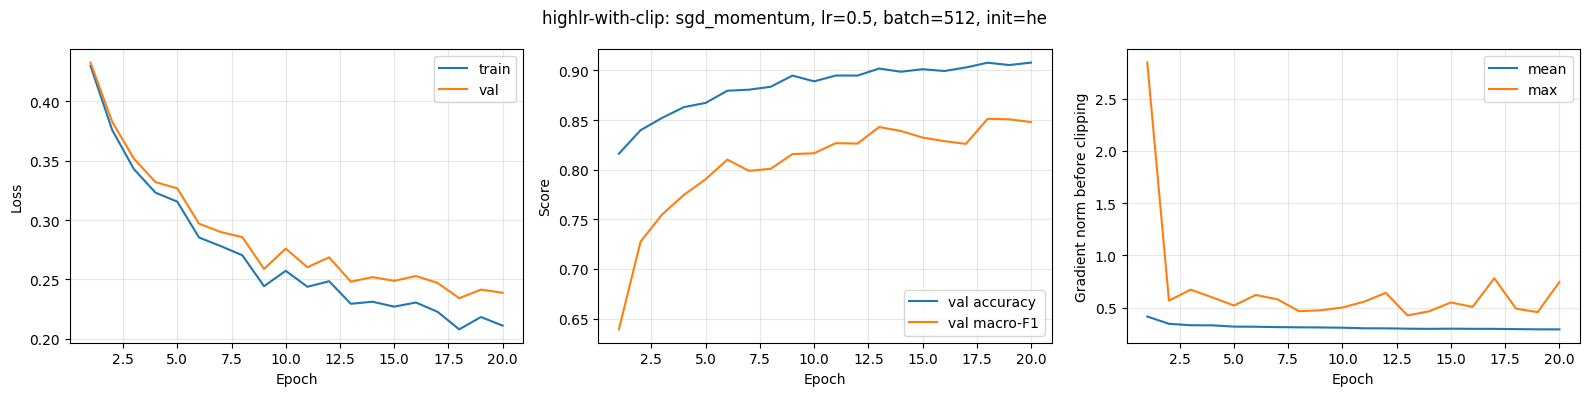

Val macro-F1: 0.8513
Chênh lệch với base-s1: +0.0103
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.
Chênh lệch macro-F1 clip - không clip ở cùng high lr: 0.010442894229817923


In [23]:
high_lr = baseline_lr * 5

high_no_clip = run_part3(
    "highlr-no-clip",
    "clipping",
    "Learning rate gấp 5 baseline có thể gây dao động hoặc phân kỳ.",
    lr=high_lr,
    clip_norm=None,
)

high_clip = run_part3(
    "highlr-with-clip",
    "clipping",
    "Clipping có thể ổn định cập nhật ở learning rate cao, "
    "nhưng không đảm bảo cứu được huấn luyện.",
    lr=high_lr,
    clip_norm=clip_threshold,
)

if not high_no_clip["diverged"] and not high_clip["diverged"]:
    print(
        "Chênh lệch macro-F1 clip - không clip ở cùng high lr:",
        high_clip["val_macro_f1"] - high_no_clip["val_macro_f1"],
    )


Thí nghiệm: amp-fp32
Dự đoán: FP32 làm mốc thời gian và bộ nhớ cho pipeline AMP.
amp-fp32 | 01/20 | train=0.4585 val=0.4634 acc=0.8012 F1=0.6236 clip=0.0% skip=0 time=1.3s
amp-fp32 | 02/20 | train=0.3927 val=0.3980 acc=0.8313 F1=0.7018 clip=0.0% skip=0 time=1.3s
amp-fp32 | 03/20 | train=0.3736 val=0.3813 acc=0.8383 F1=0.7237 clip=0.0% skip=0 time=1.3s
amp-fp32 | 04/20 | train=0.3663 val=0.3761 acc=0.8449 F1=0.7393 clip=0.0% skip=0 time=1.3s
amp-fp32 | 05/20 | train=0.3141 val=0.3228 acc=0.8669 F1=0.7756 clip=0.0% skip=0 time=1.3s
amp-fp32 | 06/20 | train=0.3053 val=0.3165 acc=0.8712 F1=0.7925 clip=0.0% skip=0 time=1.3s
amp-fp32 | 07/20 | train=0.2970 val=0.3083 acc=0.8726 F1=0.7945 clip=0.0% skip=0 time=1.3s
amp-fp32 | 08/20 | train=0.2775 val=0.2904 acc=0.8800 F1=0.8003 clip=0.0% skip=0 time=1.3s
amp-fp32 | 09/20 | train=0.2826 val=0.2986 acc=0.8806 F1=0.8101 clip=0.0% skip=0 time=1.3s
amp-fp32 | 10/20 | train=0.2692 val=0.2849 acc=0.8850 F1=0.8086 clip=0.0% skip=0 time=1.3s
amp-fp32

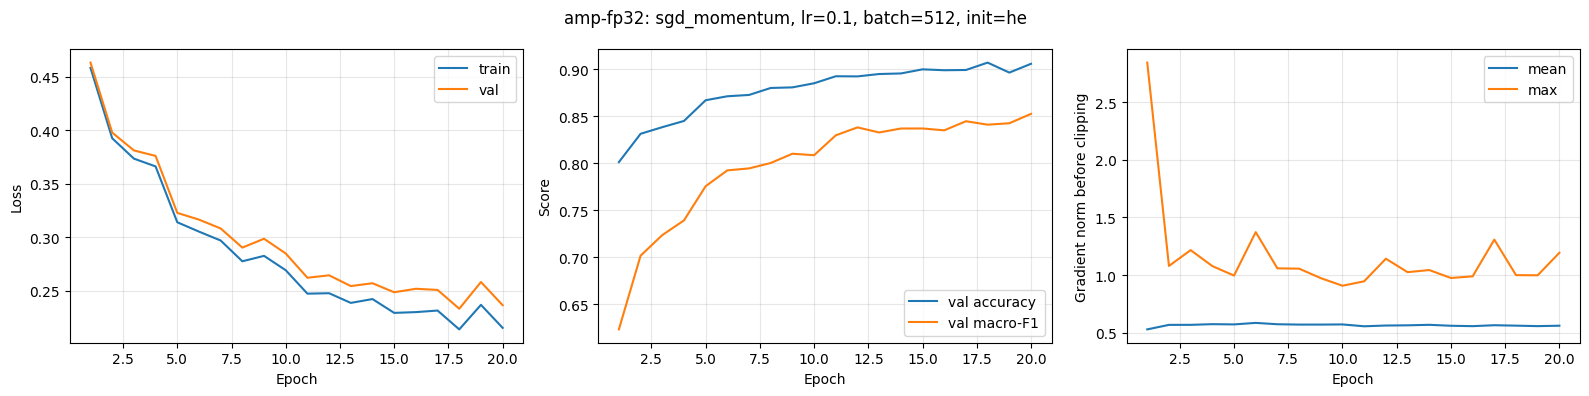

Val macro-F1: 0.8410
Chênh lệch với base-s1: +0.0000
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.

Thí nghiệm: amp-fp16
Dự đoán: FP16 có thể giảm bộ nhớ và thời gian, nhưng MLP nhỏ có thể không nhanh hơn do chi phí quản lý AMP.
amp-fp16 | 01/20 | train=0.4653 val=0.4696 acc=0.7992 F1=0.6225 clip=0.0% skip=0 time=2.0s
amp-fp16 | 02/20 | train=0.3926 val=0.3974 acc=0.8331 F1=0.7038 clip=0.0% skip=0 time=1.7s
amp-fp16 | 03/20 | train=0.3771 val=0.3845 acc=0.8367 F1=0.7247 clip=0.0% skip=0 time=1.8s
amp-fp16 | 04/20 | train=0.3903 val=0.3998 acc=0.8355 F1=0.7247 clip=0.0% skip=0 time=1.8s
amp-fp16 | 05/20 | train=0.3127 val=0.3230 acc=0.8661 F1=0.7768 clip=0.0% skip=0 time=1.8s
amp-fp16 | 06/20 | train=0.2987 val=0.3098 acc=0.8730 F1=0.7953 clip=0.0% skip=0 time=1.8s
amp-fp16 | 07/20 | train=0.2938 val=0.3057 acc=0.8743 F1=0.7975 clip=0.0% skip=0 time=1.8s
amp-fp16 | 08/20 | train=0.2703 val=0.2847 acc=0.8826 F1=0

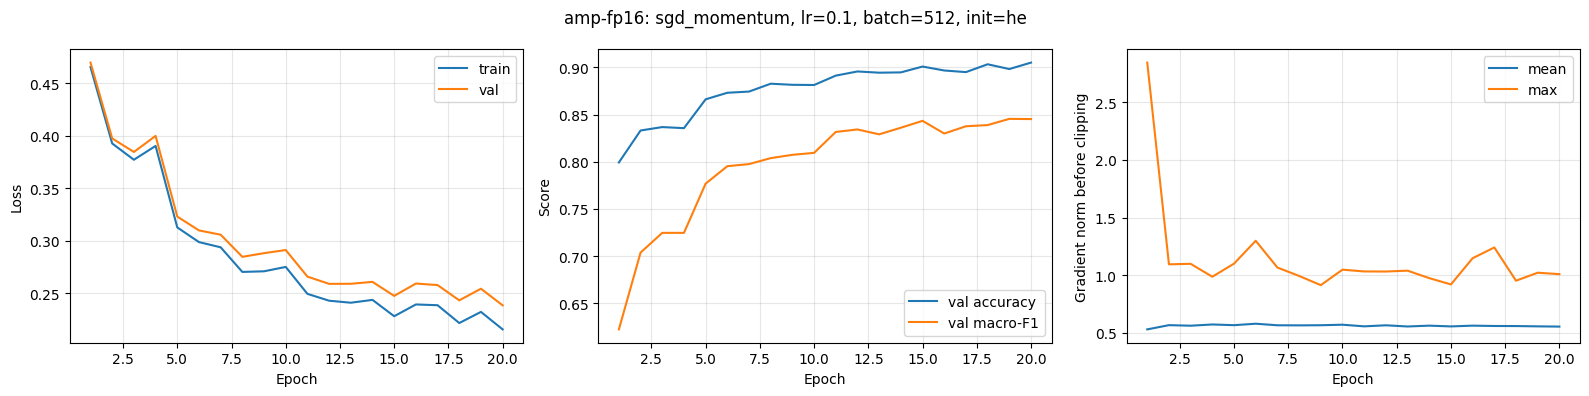

Val macro-F1: 0.8451
Chênh lệch với base-s1: +0.0042
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.

Thí nghiệm: amp-bf16
Dự đoán: BF16 có thể ổn định hơn FP16 nhờ miền biểu diễn rộng hơn.
amp-bf16 | 01/20 | train=0.4627 val=0.4673 acc=0.7991 F1=0.6196 clip=0.0% skip=0 time=1.6s
amp-bf16 | 02/20 | train=0.3963 val=0.4015 acc=0.8308 F1=0.7038 clip=0.0% skip=0 time=1.6s
amp-bf16 | 03/20 | train=0.3751 val=0.3828 acc=0.8388 F1=0.7342 clip=0.0% skip=0 time=1.6s
amp-bf16 | 04/20 | train=0.3727 val=0.3824 acc=0.8424 F1=0.7324 clip=0.0% skip=0 time=1.6s
amp-bf16 | 05/20 | train=0.3108 val=0.3205 acc=0.8662 F1=0.7784 clip=0.0% skip=0 time=1.5s
amp-bf16 | 06/20 | train=0.2981 val=0.3084 acc=0.8737 F1=0.8014 clip=0.0% skip=0 time=1.6s
amp-bf16 | 07/20 | train=0.2939 val=0.3056 acc=0.8743 F1=0.8010 clip=0.0% skip=0 time=1.5s
amp-bf16 | 08/20 | train=0.2785 val=0.2917 acc=0.8803 F1=0.8025 clip=0.0% skip=0 time=1.6s
amp-bf16

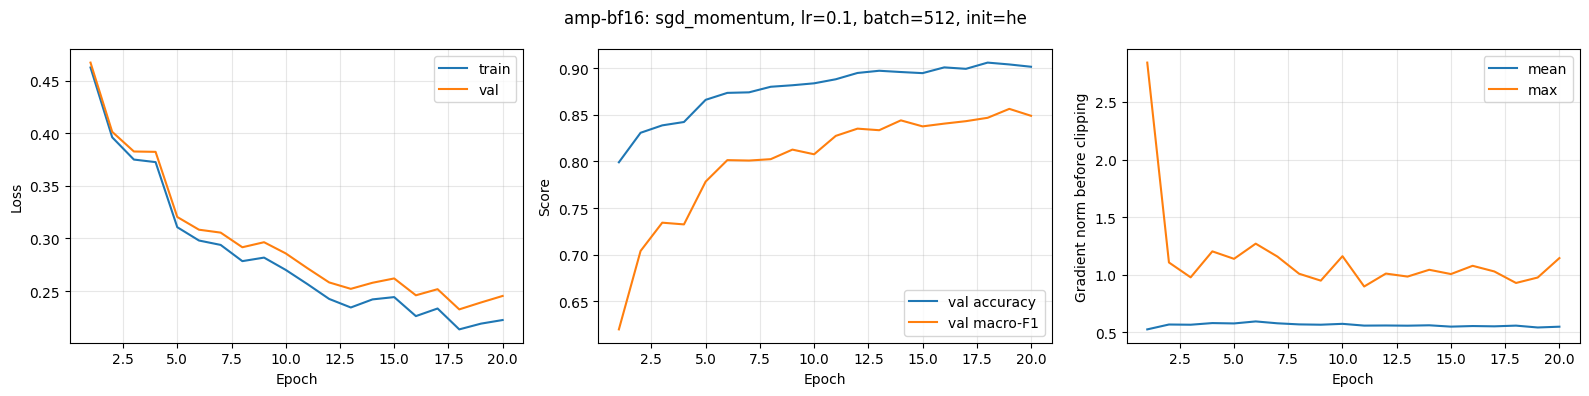

Val macro-F1: 0.8469
Chênh lệch với base-s1: +0.0059
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.


In [24]:
fp32_result = run_part3(
    "amp-fp32",
    "amp",
    "FP32 làm mốc thời gian và bộ nhớ cho pipeline AMP.",
    precision="fp32",
)

fp16_result = run_part3(
    "amp-fp16",
    "amp",
    "FP16 có thể giảm bộ nhớ và thời gian, nhưng MLP nhỏ "
    "có thể không nhanh hơn do chi phí quản lý AMP.",
    precision="fp16",
)

if torch.cuda.is_bf16_supported():
    bf16_result = run_part3(
        "amp-bf16",
        "amp",
        "BF16 có thể ổn định hơn FP16 nhờ miền biểu diễn rộng hơn.",
        precision="bf16",
    )
else:
    print("Bỏ qua BF16: GPU không hỗ trợ BF16 native.")


Thí nghiệm: init-xavier
Dự đoán: Xavier có thể tạo scale kích hoạt khác He, ảnh hưởng loss ban đầu và tốc độ hội tụ.
init-xavier | 01/20 | train=0.4896 val=0.4924 acc=0.7861 F1=0.5932 clip=0.0% skip=0 time=1.3s
init-xavier | 02/20 | train=0.4059 val=0.4101 acc=0.8270 F1=0.6851 clip=0.0% skip=0 time=1.3s
init-xavier | 03/20 | train=0.4047 val=0.4112 acc=0.8277 F1=0.6962 clip=0.0% skip=0 time=1.3s
init-xavier | 04/20 | train=0.3932 val=0.4011 acc=0.8384 F1=0.7226 clip=0.0% skip=0 time=1.3s
init-xavier | 05/20 | train=0.3231 val=0.3318 acc=0.8635 F1=0.7798 clip=0.0% skip=0 time=1.3s
init-xavier | 06/20 | train=0.3039 val=0.3127 acc=0.8716 F1=0.7977 clip=0.0% skip=0 time=1.4s
init-xavier | 07/20 | train=0.2975 val=0.3083 acc=0.8726 F1=0.7881 clip=0.0% skip=0 time=1.4s
init-xavier | 08/20 | train=0.2804 val=0.2936 acc=0.8789 F1=0.7975 clip=0.0% skip=0 time=1.3s
init-xavier | 09/20 | train=0.2824 val=0.2965 acc=0.8786 F1=0.7894 clip=0.0% skip=0 time=1.3s
init-xavier | 10/20 | train=0.2674 v

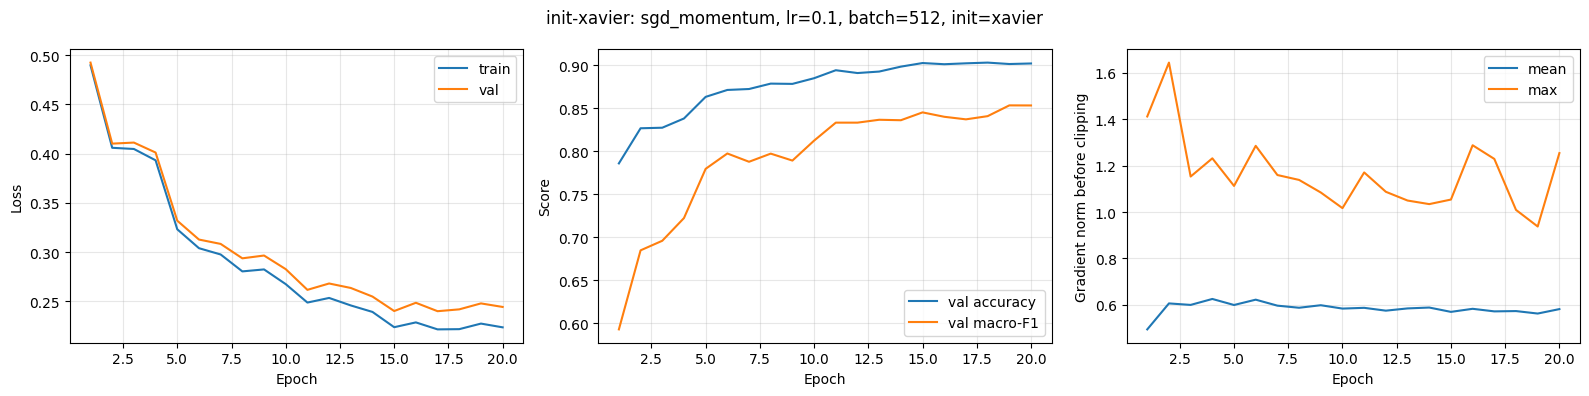

Val macro-F1: 0.8374
Chênh lệch với base-s1: -0.0036
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.

Thí nghiệm: init-zeros
Dự đoán: Khởi tạo zero khiến các lớp ẩn không học được đặc trưng; bias đầu ra có thể vẫn học phân bố lớp.
init-zeros | 01/20 | train=1.2054 val=1.2054 acc=0.4876 F1=0.0936 clip=0.0% skip=0 time=1.3s
init-zeros | 02/20 | train=1.2053 val=1.2053 acc=0.4876 F1=0.0936 clip=0.0% skip=0 time=1.3s
init-zeros | 03/20 | train=1.2054 val=1.2054 acc=0.4876 F1=0.0936 clip=0.0% skip=0 time=1.3s
init-zeros | 04/20 | train=1.2052 val=1.2052 acc=0.4876 F1=0.0936 clip=0.0% skip=0 time=1.3s
init-zeros | 05/20 | train=1.2053 val=1.2053 acc=0.4876 F1=0.0936 clip=0.0% skip=0 time=1.3s
init-zeros | 06/20 | train=1.2053 val=1.2053 acc=0.4876 F1=0.0936 clip=0.0% skip=0 time=1.2s
init-zeros | 07/20 | train=1.2052 val=1.2052 acc=0.4876 F1=0.0936 clip=0.0% skip=0 time=1.3s
init-zeros | 08/20 | train=1.2056 val=1.2056

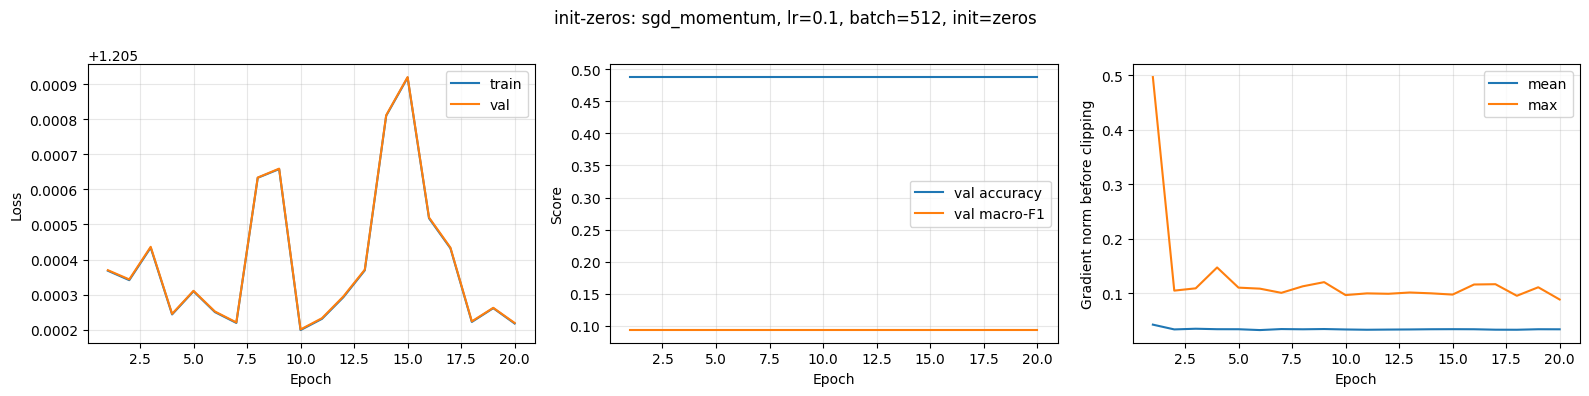

Val macro-F1: 0.0936
Chênh lệch với base-s1: -0.7473
Mốc nhiễu baseline 2σ: 0.0238
Cần nhận xét thêm đường cong và cơ chế; một seed chưa đủ
để khẳng định khác biệt chắc chắn.


In [25]:
xavier_result = run_part3(
    "init-xavier",
    "init",
    "Xavier có thể tạo scale kích hoạt khác He, "
    "ảnh hưởng loss ban đầu và tốc độ hội tụ.",
    init="xavier",
)

zeros_result = run_part3(
    "init-zeros",
    "init",
    "Khởi tạo zero khiến các lớp ẩn không học được đặc trưng; "
    "bias đầu ra có thể vẫn học phân bố lớp.",
    init="zeros",
)

In [26]:
def summary_row(result):
    history = result["history"]
    return {
        "exp_id": result["cfg"]["exp_id"],
        "group": result["cfg"]["group"],
        "optimizer": result["cfg"]["optimizer"],
        "lr": result["cfg"]["lr"],
        "batch": result["cfg"]["batch"],
        "loss": result["cfg"]["loss"],
        "dropout": result["cfg"]["dropout"],
        "clip_norm": result["cfg"]["clip_norm"],
        "precision": result["cfg"]["precision"],
        "init": result["cfg"]["init"],
        "initial_val_loss": result["initial_val_loss"],
        "best_epoch": result["best_epoch"],
        "val_acc": result["val_acc"],
        "val_macro_f1": result["val_macro_f1"],
        "delta_f1_vs_base_s1": (
            None if result["val_macro_f1"] is None
            else result["val_macro_f1"] - base["val_macro_f1"]
        ),
        "mean_epoch_seconds": (
            np.mean([r["seconds"] for r in history]) if history else None
        ),
        "mean_train_seconds": (
            np.mean([r["train_seconds"] for r in history])
            if history and "train_seconds" in history[0] else None
        ),
        "peak_memory_mb": result["peak_memory_mb"],
        "mean_clip_fraction": (
            np.mean([r["clip_fraction"] for r in history])
            if history and "clip_fraction" in history[0] else None
        ),
        "diverged": result["diverged"],
    }

part3_table = pd.DataFrame([
    summary_row(r) for r in [base, *part3_results]
])

display(part3_table)
part3_table.to_csv(
    OUT_DIR / "results" / "part3_summary.csv", index=False
)

# AMP: so sánh thời gian phần train, kèm bộ nhớ và điểm.
amp_table = part3_table[part3_table["group"] == "amp"]
display(amp_table[[
    "exp_id", "precision", "mean_train_seconds",
    "peak_memory_mb", "val_macro_f1", "diverged"
]])

print("Đã lưu:", OUT_DIR / "results" / "part3_summary.csv")

,exp_id,group,optimizer,lr,batch,loss,dropout,clip_norm,precision,init,initial_val_loss,best_epoch,val_acc,val_macro_f1,delta_f1_vs_base_s1,mean_epoch_seconds,mean_train_seconds,peak_memory_mb,mean_clip_fraction,diverged
0,base-s1,baseline,sgd_momentum,0.100,512,ce,0.0,NaN,fp32,he,2.269062,18,0.906897,0.840989,0.000000,1.274550,NaN,161.120605,NaN,False
1,loss-mse,loss,sgd_momentum,0.100,512,mse,0.0,NaN,fp32,he,0.137251,20,0.873895,0.744343,-0.096646,1.407453,1.352829,161.127930,0.000000,False
2,opt-adam-lr1e-3,optimizer,adam,0.001,512,ce,0.0,NaN,fp32,he,2.269062,20,0.901358,0.847647,0.006657,1.462033,1.409888,161.307617,0.000000,False
3,hparam-batch1024,hparam,sgd_momentum,0.100,1024,ce,0.0,NaN,fp32,he,2.269062,18,0.892591,0.816580,-0.024410,0.696922,0.646586,161.124512,0.000000,False
4,dropout-p02,dropout,sgd_momentum,0.100,512,ce,0.2,NaN,fp32,he,2.269062,20,0.887513,0.816630,-0.024359,1.437448,1.384246,161.124512,0.000000,False
5,clip-normal-lr,clipping,sgd_momentum,0.100,512,ce,0.0,0.283431,fp32,he,2.269062,18,0.897055,0.825499,-0.015490,1.384868,1.331420,161.124512,0.999862,False
6,highlr-no-clip,clipping,sgd_momentum,0.500,512,ce,0.0,NaN,fp32,he,2.269062,20,0.904488,0.840828,-0.000161,1.294504,1.241748,161.124512,0.000000,False
7,highlr-with-clip,clipping,sgd_momentum,0.500,512,ce,0.0,0.283431,fp32,he,2.269062,18,0.907790,0.851271,0.010282,1.388073,1.334514,161.124512,0.768088,False
8,amp-fp32,amp,sgd_momentum,0.100,512,ce,0.0,NaN,fp32,he,2.269062,18,0.906897,0.840989,0.000000,1.288592,1.235950,161.124512,0.000000,False
9,amp-fp16,amp,sgd_momentum,0.100,512,ce,0.0,NaN,fp16,he,2.269062,20,0.904940,0.845148,0.004159,1.794812,1.740681,161.123535,0.000000,False


,exp_id,precision,mean_train_seconds,peak_memory_mb,val_macro_f1,diverged
8,amp-fp32,fp32,1.235950,161.124512,0.840989,False
9,amp-fp16,fp16,1.740681,161.123535,0.845148,False
10,amp-bf16,bf16,1.497728,161.122559,0.846920,False


Đã lưu: /kaggle/working/day1-lab/submission_YOUR_MSSV/results/part3_summary.csv


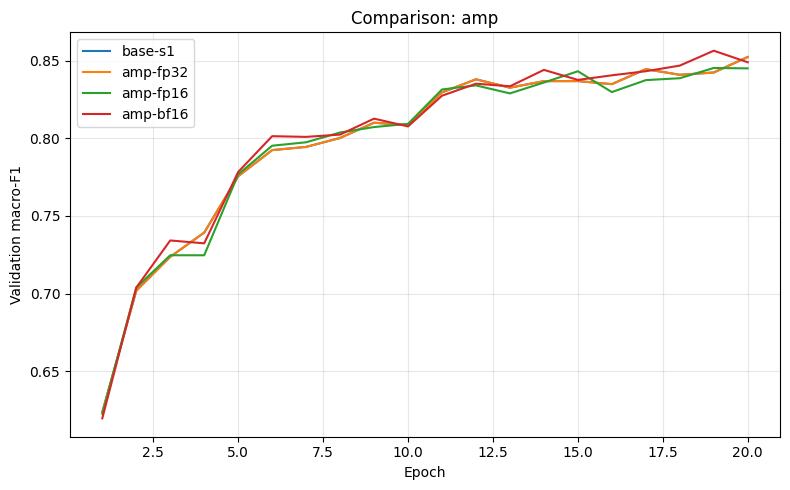

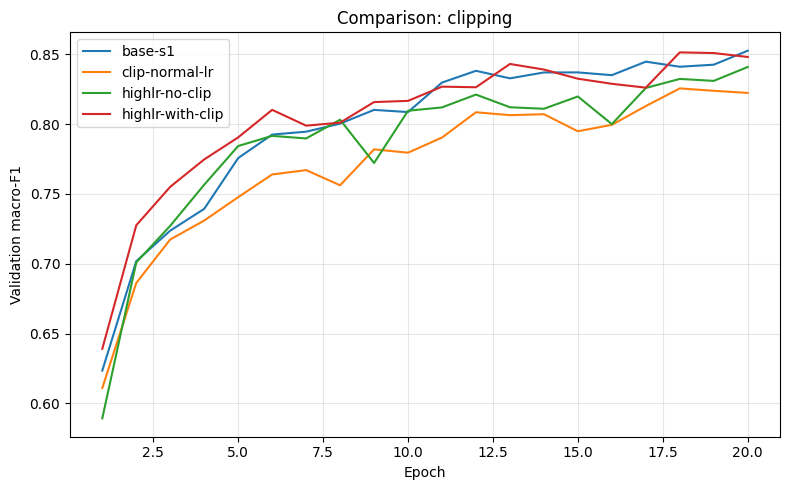

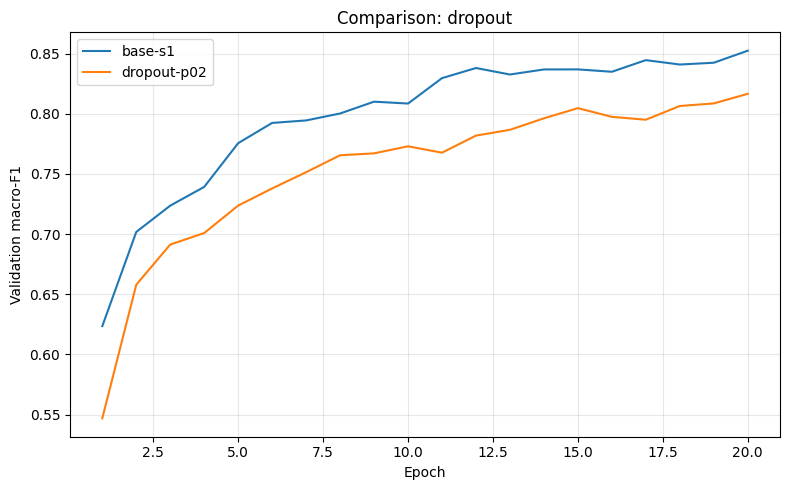

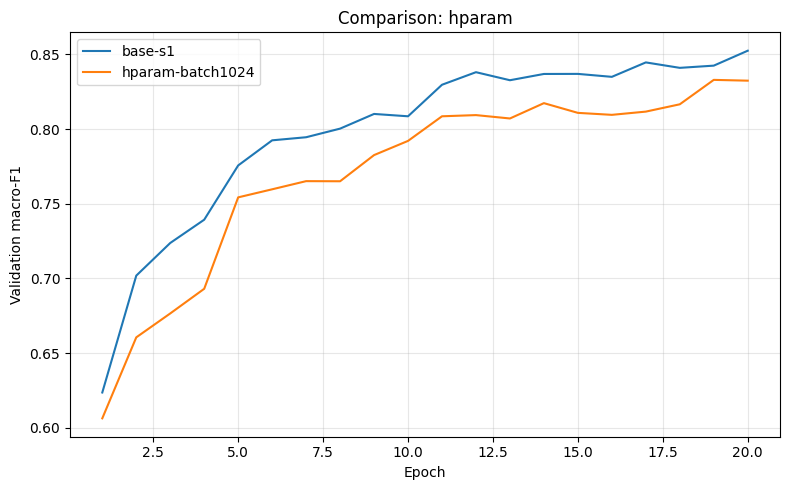

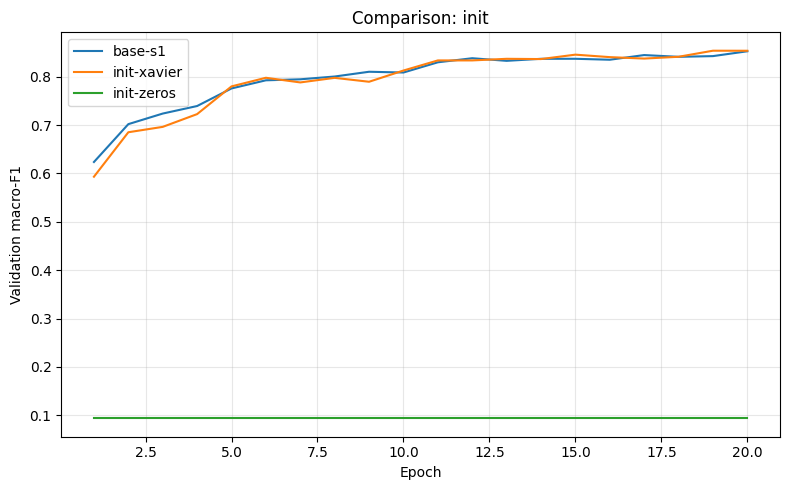

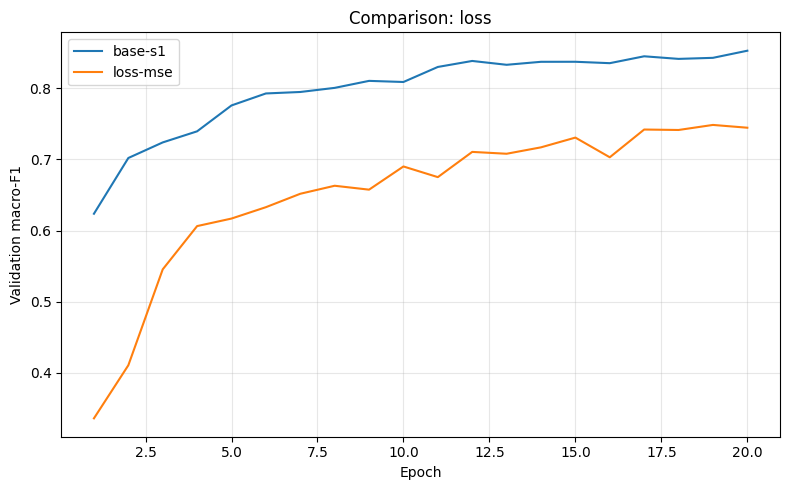

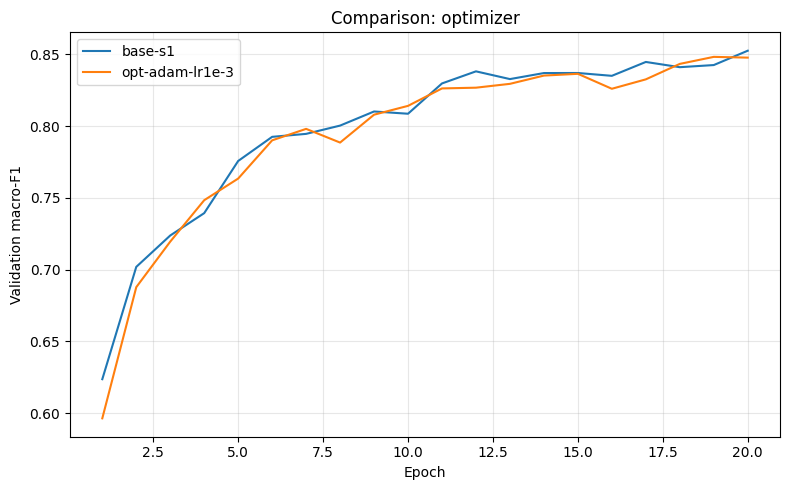

In [27]:
import matplotlib.pyplot as plt

groups = sorted({r["cfg"]["group"] for r in part3_results})

for group in groups:
    runs = [base] + [
        r for r in part3_results if r["cfg"]["group"] == group
    ]
    fig, ax = plt.subplots(figsize=(8, 5))

    for result in runs:
        history = result["history"]
        if not history:
            continue
        ax.plot(
            [row["epoch"] for row in history],
            [row["val_macro_f1"] for row in history],
            label=result["cfg"]["exp_id"],
        )

    ax.set(
        xlabel="Epoch",
        ylabel="Validation macro-F1",
        title=f"Comparison: {group}",
    )
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        OUT_DIR / "figures" / f"compare_{group}.png", dpi=150
    )
    plt.show()
    plt.close(fig)

# PART 4

highlr-with-clip-s2 | 01/20 | train=0.4573 val=0.4622 acc=0.8020 F1=0.6455 clip=92.3% skip=0 time=1.4s
highlr-with-clip-s2 | 02/20 | train=0.3669 val=0.3741 acc=0.8449 F1=0.7189 clip=89.3% skip=0 time=1.4s
highlr-with-clip-s2 | 03/20 | train=0.3512 val=0.3617 acc=0.8521 F1=0.7626 clip=88.2% skip=0 time=1.4s
highlr-with-clip-s2 | 04/20 | train=0.3253 val=0.3373 acc=0.8618 F1=0.7691 clip=80.5% skip=0 time=1.4s
highlr-with-clip-s2 | 05/20 | train=0.3024 val=0.3122 acc=0.8758 F1=0.7895 clip=77.6% skip=0 time=1.3s
highlr-with-clip-s2 | 06/20 | train=0.2929 val=0.3072 acc=0.8755 F1=0.7947 clip=75.5% skip=0 time=1.4s
highlr-with-clip-s2 | 07/20 | train=0.2905 val=0.3041 acc=0.8733 F1=0.7994 clip=73.5% skip=0 time=1.3s
highlr-with-clip-s2 | 08/20 | train=0.2570 val=0.2717 acc=0.8918 F1=0.8237 clip=69.1% skip=0 time=1.3s
highlr-with-clip-s2 | 09/20 | train=0.2548 val=0.2734 acc=0.8908 F1=0.8269 clip=67.7% skip=0 time=1.4s
highlr-with-clip-s2 | 10/20 | train=0.2449 val=0.2630 acc=0.8935 F1=0.825

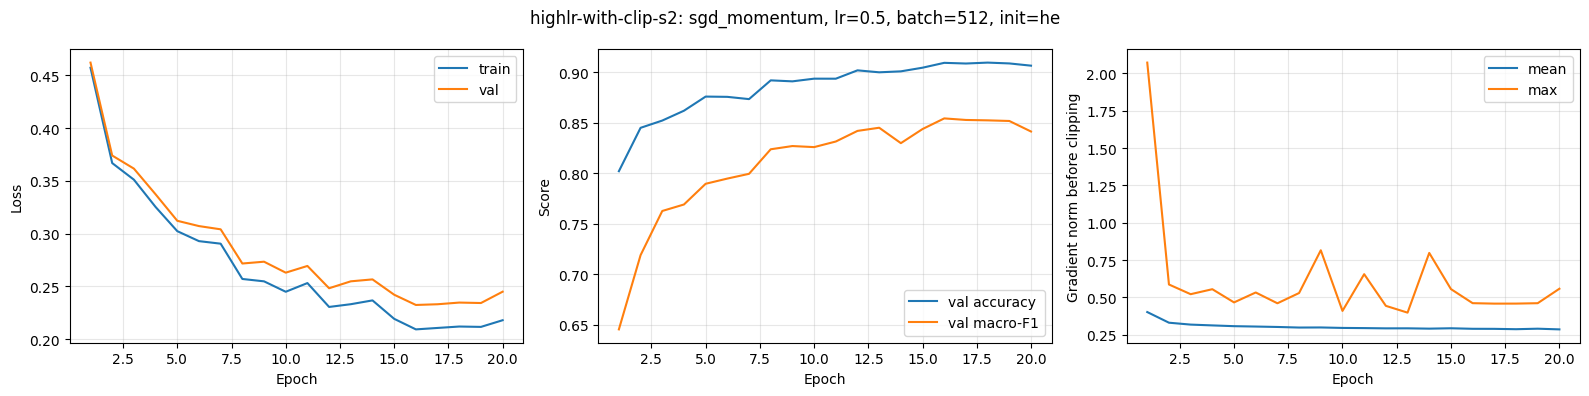

highlr-with-clip-s3 | 01/20 | train=0.4485 val=0.4528 acc=0.8087 F1=0.6497 clip=95.2% skip=0 time=1.4s
highlr-with-clip-s3 | 02/20 | train=0.3745 val=0.3828 acc=0.8409 F1=0.7093 clip=92.2% skip=0 time=1.4s
highlr-with-clip-s3 | 03/20 | train=0.3375 val=0.3459 acc=0.8540 F1=0.7781 clip=91.3% skip=0 time=1.4s
highlr-with-clip-s3 | 04/20 | train=0.3167 val=0.3268 acc=0.8671 F1=0.7557 clip=88.9% skip=0 time=1.4s
highlr-with-clip-s3 | 05/20 | train=0.3003 val=0.3126 acc=0.8710 F1=0.7898 clip=85.4% skip=0 time=1.4s
highlr-with-clip-s3 | 06/20 | train=0.2856 val=0.2996 acc=0.8770 F1=0.7996 clip=84.5% skip=0 time=1.4s
highlr-with-clip-s3 | 07/20 | train=0.2667 val=0.2812 acc=0.8868 F1=0.8118 clip=80.3% skip=0 time=1.4s
highlr-with-clip-s3 | 08/20 | train=0.2622 val=0.2781 acc=0.8884 F1=0.8112 clip=80.7% skip=0 time=1.4s
highlr-with-clip-s3 | 09/20 | train=0.2582 val=0.2757 acc=0.8891 F1=0.8053 clip=75.0% skip=0 time=1.4s
highlr-with-clip-s3 | 10/20 | train=0.2390 val=0.2575 acc=0.8985 F1=0.836

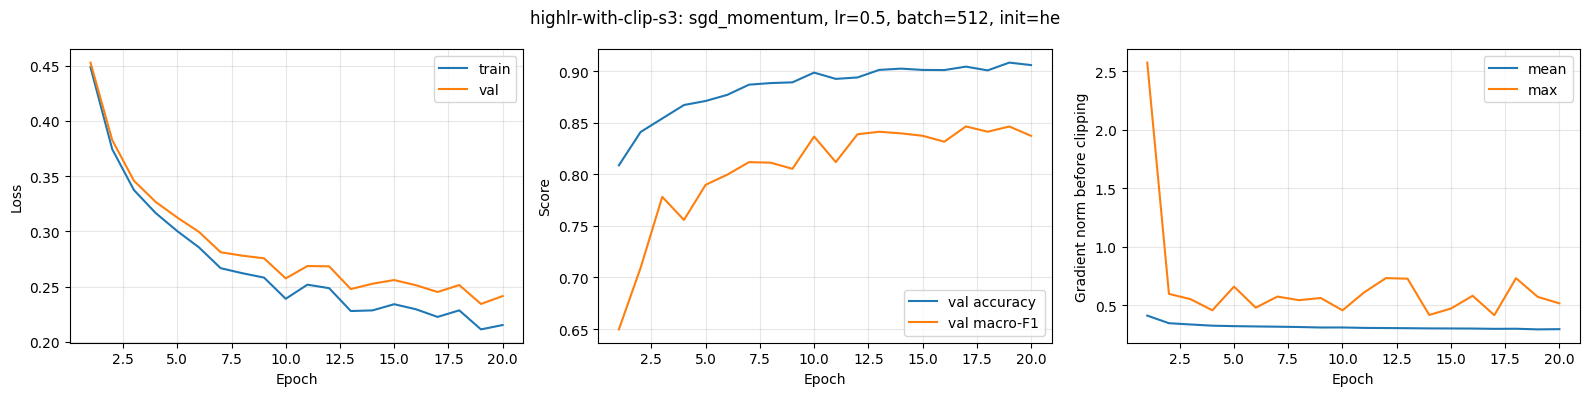

,seed,baseline_f1,candidate_f1,paired_delta
0,1,0.840989,0.851271,0.010282
1,2,0.863947,0.854202,-0.009745
2,3,0.857861,0.846280,-0.011581


{
  "selection_rule": "Higher mean validation macro-F1 across seeds 1,2,3; ties use baseline",
  "baseline_mean_f1": 0.8542656551567207,
  "baseline_std_f1": 0.01189376265311929,
  "candidate_mean_f1": 0.8505843413232342,
  "candidate_std_f1": 0.004005374973295701,
  "final_exp_id": "base-s1",
  "submission_seed": 1,
  "checkpoint_rule": "Lowest validation loss within each run"
}
Đã chốt cấu hình. Không đổi cấu hình sau khi xem eval.


In [28]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

REPO_ROOT = Path(REPO_ROOT)
OUT_DIR = Path(OUT_DIR)

baseline_runs = [all_results[f"base-s{s}"] for s in [1, 2, 3]]
candidate_runs = [all_results["highlr-with-clip"]]

for seed in [2, 3]:
    exp_id = f"highlr-with-clip-s{seed}"
    if exp_id not in all_results:
        cfg = {
            **candidate_runs[0]["cfg"],
            "exp_id": exp_id,
            "group": "final",
            "seed": seed,
            "description": "Confirm high-lr clipping candidate across seeds",
        }
        result = run_experiment(cfg, data)
        save_and_plot(result)
        all_results[exp_id] = result

    candidate_runs.append(all_results[exp_id])

base_f1 = np.array([r["val_macro_f1"] for r in baseline_runs])
candidate_valid = all(
    not r["diverged"] and r["val_macro_f1"] is not None
    for r in candidate_runs
)

comparison = pd.DataFrame({
    "seed": [1, 2, 3],
    "baseline_f1": base_f1,
    "candidate_f1": [
        r["val_macro_f1"] for r in candidate_runs
    ],
})
comparison["paired_delta"] = (
    comparison["candidate_f1"] - comparison["baseline_f1"]
)
display(comparison)

# Quy tắc chọn được áp dụng chỉ bằng validation.
# Nếu ứng viên không cải thiện trung bình, giữ baseline.
candidate_mean = (
    float(np.mean([r["val_macro_f1"] for r in candidate_runs]))
    if candidate_valid else None
)
choose_candidate = (
    candidate_valid and candidate_mean > float(base_f1.mean())
)

final_result = candidate_runs[0] if choose_candidate else baseline_runs[0]
baseline_result = baseline_runs[0]

decision = {
    "selection_rule": "Higher mean validation macro-F1 across seeds 1,2,3; ties use baseline",
    "baseline_mean_f1": float(base_f1.mean()),
    "baseline_std_f1": float(base_f1.std(ddof=1)),
    "candidate_mean_f1": candidate_mean,
    "candidate_std_f1": (
        float(np.std([r["val_macro_f1"] for r in candidate_runs], ddof=1))
        if candidate_valid else None
    ),
    "final_exp_id": final_result["cfg"]["exp_id"],
    "submission_seed": 1,
    "checkpoint_rule": "Lowest validation loss within each run",
}
(OUT_DIR / "results/final_selection.json").write_text(
    json.dumps(decision, indent=2), encoding="utf-8"
)

print(json.dumps(decision, indent=2))
print("Đã chốt cấu hình. Không đổi cấu hình sau khi xem eval.")

In [29]:
import subprocess
import sys
import torch
from model import MLP

raw_data = next(
    (p for p in [
        REPO_ROOT / "data/covtype.csv.gz",
        REPO_ROOT / "data/covtype.csv",
    ] if p.is_file()),
    None,
)
assert raw_data is not None, "Không tìm thấy dữ liệu CSV gốc"

def export_and_score(result, pred_name, score_name):
    pred_path = OUT_DIR / pred_name
    score_path = OUT_DIR / score_name
    marker = score_path.with_suffix(".selection.json")

    identity = {
        "exp_id": result["cfg"]["exp_id"],
        "cfg": result["cfg"],
        "best_epoch": result["best_epoch"],
    }
    # Chuẩn hoá tuple thành list như khi ghi JSON.
    identity = json.loads(json.dumps(identity))

    if score_path.exists():
        if not marker.exists():
            raise RuntimeError("Có score cũ nhưng thiếu thông tin model.")
        assert json.loads(marker.read_text()) == identity, (
            "Score cũ thuộc cấu hình khác. Không thay model sau khi xem eval."
        )
        assert pred_path.is_file()
        return json.loads(score_path.read_text())

    assert result["best_state"] is not None, "Trọng số không còn trong RAM"
    cfg = result["cfg"]
    model_eval = MLP(
        hidden=tuple(cfg["hidden"]),
        dropout=cfg["dropout"],
        init=cfg["init"],
    ).to(data["X_eval"].device)
    model_eval.load_state_dict(result["best_state"])
    model_eval.eval()

    predictions = []
    with torch.no_grad():
        for start in range(0, len(data["X_eval"]), 8192):
            logits = model_eval(data["X_eval"][start:start + 8192])
            predictions.append(logits.argmax(1).cpu().numpy())

    frame = pd.DataFrame({
        "row_id": data["eval_row_id"],
        "pred": np.concatenate(predictions),
    })
    assert len(frame) == 116203
    assert frame["row_id"].is_unique
    assert frame["pred"].between(0, 6).all()
    frame.to_csv(pred_path, index=False)

    subprocess.run([
        sys.executable,
        str(REPO_ROOT / "scripts/evaluate.py"),
        "--data", str(raw_data),
        "--meta", str(REPO_ROOT / "data/split_metadata.csv"),
        "--pred", str(pred_path),
        "--out", str(score_path),
    ], cwd=REPO_ROOT, check=True)

    marker.write_text(json.dumps(identity, indent=2), encoding="utf-8")
    del model_eval
    return json.loads(score_path.read_text())

baseline_eval = export_and_score(
    baseline_result,
    "predictions_baseline.csv",
    "eval_baseline.json",
)

if final_result["cfg"]["exp_id"] == baseline_result["cfg"]["exp_id"]:
    import shutil
    shutil.copy2(
        OUT_DIR / "predictions_baseline.csv",
        OUT_DIR / "predictions_eval.csv",
    )
    shutil.copy2(
        OUT_DIR / "eval_baseline.json",
        OUT_DIR / "eval_result.json",
    )
    final_eval_scores = baseline_eval
else:
    final_eval_scores = export_and_score(
        final_result,
        "predictions_eval.csv",
        "eval_result.json",
    )

display(pd.DataFrame([
    {
        "role": role,
        "exp_id": result["cfg"]["exp_id"],
        "val_macro_f1": result["val_macro_f1"],
        "eval_macro_f1": scores["macro_f1"],
        "eval_accuracy": scores["accuracy"],
    }
    for role, result, scores in [
        ("baseline", baseline_result, baseline_eval),
        ("final", final_result, final_eval_scores),
    ]
]))

n_eval = 116203
accuracy = 0.9043
macro_f1 = 0.8427   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9106  0.8947  0.9026
  1    56661     0.9083  0.9342  0.9211
  2     7151     0.8655  0.9171  0.8905
  3      549     0.8227  0.7523  0.7859
  4     1899     0.8485  0.6251  0.7198
  5     3473     0.8418  0.7244  0.7787
  6     4102     0.9324  0.8708  0.9005

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37906   4195     0    0    22     7   238
1   3169  52935   220    2   168   146    21
2     12    218  6558   62    20   281     0
3      0      0   108  413     0    28     0
4     79    606    16    0  1187    11     0
5     15    240   675   25     2  2516     0
6    446     84     0    0     0     0  3572

đã ghi /kaggle/working/day1-lab/submission_YOUR_MSSV/eval_baseline.json


,role,exp_id,val_macro_f1,eval_macro_f1,eval_accuracy
0,baseline,base-s1,0.840989,0.842746,0.90434
1,final,base-s1,0.840989,0.842746,0.90434


,cls,support,precision,recall,f1
0,0,42368,0.910611,0.894685,0.902578
1,1,56661,0.908319,0.934240,0.921097
2,2,7151,0.865514,0.917075,0.890549
3,3,549,0.822709,0.752277,0.785918
4,4,1899,0.848463,0.625066,0.719830
5,5,3473,0.841753,0.724446,0.778706
6,6,4102,0.932394,0.870795,0.900542


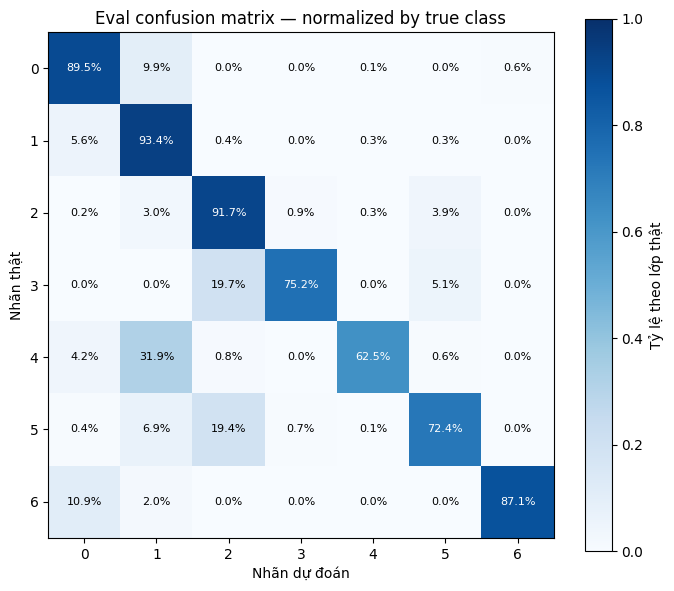

Lớp có F1 thấp nhất: 4
Thường nhầm sang lớp: 1
Đây là quan sát; nguyên nhân cần được trình bày như giả thuyết.


In [30]:
import matplotlib.pyplot as plt

per_class = pd.DataFrame(final_eval_scores["per_class"])
display(per_class)

cm = np.array(final_eval_scores["confusion_matrix"])
normalized = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
fig.colorbar(image, ax=ax, label="Tỷ lệ theo lớp thật")

for i in range(7):
    for j in range(7):
        ax.text(
            j, i, f"{normalized[i, j]:.1%}",
            ha="center", va="center",
            color="white" if normalized[i, j] > 0.5 else "black",
            fontsize=8,
        )

ax.set(
    xticks=range(7), yticks=range(7),
    xlabel="Nhãn dự đoán", ylabel="Nhãn thật",
    title="Eval confusion matrix — normalized by true class",
)
fig.tight_layout()
fig.savefig(OUT_DIR / "figures/eval_confusion.png", dpi=150)
plt.show()
plt.close(fig)

hardest = int(per_class.loc[per_class["f1"].idxmin(), "cls"])
mistakes = cm[hardest].copy()
mistakes[hardest] = 0
confused_with = int(mistakes.argmax()) if mistakes.sum() else None

print("Lớp có F1 thấp nhất:", hardest)
print("Thường nhầm sang lớp:", confused_with)
print("Đây là quan sát; nguyên nhân cần được trình bày như giả thuyết.")

In [31]:
%%writefile results_table.py
import json
from pathlib import Path
from copy import copy
import numpy as np
from openpyxl import load_workbook
from openpyxl.formula.translate import Translator
from openpyxl.workbook.properties import CalcProperties

def save_result(result, results_dir="../results"):
    directory = Path(results_dir)
    directory.mkdir(parents=True, exist_ok=True)
    path = directory / f"{result['cfg']['exp_id']}.json"
    payload = {k: v for k, v in result.items() if k != "best_state"}
    path.write_text(
        json.dumps(payload, indent=2, allow_nan=False), encoding="utf-8"
    )
    return str(path)

def load_results(results_dir="../results"):
    results = []
    for path in sorted(Path(results_dir).glob("*.json")):
        result = json.loads(path.read_text(encoding="utf-8"))
        if isinstance(result, dict) and "cfg" in result and "history" in result:
            results.append(result)
    return results

def to_row(result, eval_scores=None, notes=""):
    cfg = result["cfg"]
    history = result["history"]
    last = history[-1] if history else {}
    row = dict(cfg)
    row.update(
        hidden="→".join(map(str, cfg["hidden"])),
        step0_loss=result["initial_val_loss"],
        best_val_loss=result["best_val_loss"],
        best_epoch=result["best_epoch"],
        final_train_loss=last.get("train_loss"),
        final_val_loss=last.get("val_loss"),
        val_acc=result["val_acc"],
        val_macro_f1=result["val_macro_f1"],
        time_per_epoch_s=(
            float(np.mean([r["seconds"] for r in history]))
            if history else None
        ),
        peak_mem_MB=result["peak_memory_mb"],
        diverged=result["diverged"],
        eval_acc=None if eval_scores is None else eval_scores["accuracy"],
        eval_macro_f1=None if eval_scores is None else eval_scores["macro_f1"],
        figure_file=f"figures/{cfg['exp_id']}.png",
        notes=notes,
    )
    if result["diverged"]:
        row["notes"] += " Diverged; metrics may describe an earlier checkpoint."
    return row

def write_xlsx(rows, template_path, out_path):
    wb = load_workbook(template_path)
    ws = wb["Experiments"]
    headers = {cell.column: cell.value for cell in ws[1]}
    formula_columns = {
        "step0_gap_vs_lnC", "gap_val_minus_train",
        "delta_val_f1_vs_base", "beyond_noise",
    }

    # Clear template example values while preserving formulas.
    for cells in ws.iter_rows(min_row=2):
        for cell in cells:
            if cell.data_type != "f":
                cell.value = None

    for index, row in enumerate(rows, start=2):
        for column, name in headers.items():
            target = ws.cell(index, column)
            source = ws.cell(2, column)
            if index > 2:
                target._style = copy(source._style)
            if name in formula_columns:
                if source.data_type == "f":
                    target.value = Translator(
                        source.value, origin=source.coordinate
                    ).translate_formula(target.coordinate)
            elif name in row:
                target.value = row[name]

    # Template calculations cover rows 2–61.
    assert len(rows) <= 60, "Extend template formula ranges for more than 60 runs"
    wb.calculation = CalcProperties(
        calcMode="auto", fullCalcOnLoad=True, forceFullCalc=True
    )
    wb.save(out_path)

Overwriting results_table.py


In [32]:
import importlib
import results_table
importlib.reload(results_table)

# Ghi tất cả kết quả đang giữ, gồm cả các lần xác nhận seed mới.
for result in all_results.values():
    results_table.save_result(result, OUT_DIR / "results")

records = results_table.load_results(OUT_DIR / "results")
ids = [r["cfg"]["exp_id"] for r in records]
assert len(ids) == len(set(ids))

eval_by_id = {
    baseline_result["cfg"]["exp_id"]: baseline_eval,
    final_result["cfg"]["exp_id"]: final_eval_scores,
}

rows = []
for result in records:
    exp_id = result["cfg"]["exp_id"]
    notes = "Checkpoint selected by minimum validation loss."

    if result["cfg"]["group"] == "lr_search":
        notes += " 5-epoch pilot; not a 20-epoch comparison."
    if exp_id == final_result["cfg"]["exp_id"]:
        notes += " Final submission model; seed fixed to 1."
    if exp_id == "opt-adam-lr1e-3":
        notes += " Optimizer and learning rate both changed; Adam not fully tuned."
    if exp_id == "amp-bf16":
        notes += "Execution supported by runtime; native hardware support not verified."

    rows.append(results_table.to_row(
        result, eval_by_id.get(exp_id), notes
    ))

results_table.write_xlsx(
    rows,
    REPO_ROOT / "templates/experiment_table_template.xlsx",
    OUT_DIR / "experiments.xlsx",
)

from openpyxl import load_workbook
wb = load_workbook(OUT_DIR / "experiments.xlsx")

# Seeds: chỉ ghi exp_id, giữ công thức tra cứu và thống kê.
for row_index, seed in enumerate([1, 2, 3], start=2):
    wb["Seeds"].cell(row_index, 1, f"base-s{seed}")
for row_index in [5, 6]:
    wb["Seeds"].cell(row_index, 1).value = None

comments = {
    "baseline": "3 seeds; use mean and sample standard deviation.",
    "loss": "Compare F1/accuracy, not numerical CE vs MSE loss.",
    "optimizer": "Adam lr=0.001; optimizer comparison not fully tuned.",
    "hparam": "Larger batch reduces update count per epoch.",
    "dropout": "Interpret together with train/validation loss gap.",
    "clipping": "Use matched high-lr pair and measured clip frequency.",
    "amp": "Compare matched FP32/AMP training times and memory.",
    "init": "Zero initialization fails to learn useful hidden features.",
    "final": "Configuration selected using validation only.",
}
for row_index in range(2, 12):
    group = wb["Summary"].cell(row_index, 1).value
    wb["Summary"].cell(row_index, 8, comments.get(group, ""))

wb.save(OUT_DIR / "experiments.xlsx")
print("Đã tạo experiments.xlsx với", len(rows), "thí nghiệm.")

Đã tạo experiments.xlsx với 20 thí nghiệm.


In [33]:
HO_TEN = "Văn Thành Huy"
MSSV = "2A202602763"

def md_table(frame):
    # Không cần cài thêm tabulate.
    columns = list(frame.columns)
    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for values in frame.itertuples(index=False, name=None):
        formatted = [
            f"{v:.4f}" if isinstance(v, (float, np.floating)) else str(v)
            for v in values
        ]
        lines.append("| " + " | ".join(formatted) + " |")
    return "\n".join(lines)

lookup = {r["cfg"]["exp_id"]: r for r in records}
noise = 2 * float(base_f1.std(ddof=1))

health = json.loads(
    (OUT_DIR / "results/health_checks.json").read_text()
)

mechanisms = {
    "loss": "CE tác động trực tiếp lên logit; MSE trên softmax có gradient "
            "khác và có thể cần learning rate khác. Kết quả chỉ áp dụng "
            "cho cấu hình đã thử.",
    "optimizer": "Adam điều chỉnh bước cập nhật theo thống kê gradient. "
                 "Thí nghiệm đồng thời đổi optimizer và learning rate; "
                 "chưa chứng minh optimizer nào tốt nhất khi tune công bằng.",
    "hparam": "Batch 1024 có khoảng một nửa số bước cập nhật mỗi epoch "
             "so với batch 512. Cùng số epoch không đồng nghĩa cùng số bước.",
    "dropout": "Dropout tạo nhiễu và giảm khả năng đồng thích nghi. "
              "Nếu model còn thiếu khớp, regularization có thể làm điểm giảm. "
              "Cần xem khoảng cách train–val trước khi kết luận.",
    "clipping": "Clipping giới hạn norm gradient. So sánh tác dụng tại lr cao "
                "bằng cặp highlr-no-clip/highlr-with-clip; clipping không "
                "đảm bảo cứu được mọi learning rate.",
    "amp": "AMP thay đổi precision trong forward/backward. Với mạng nhỏ, "
           "chi phí autocast và GradScaler có thể lớn hơn lợi ích tính toán. "
           "Bộ nhớ ở đây là peak allocated của PyTorch, gồm dữ liệu resident.",
    "init": "He dùng variance 2/fan_in, phù hợp ReLU; Xavier dùng "
            "2/(fan_in+fan_out). Khởi tạo zero làm các lớp ẩn không học "
            "được đặc trưng, dù bias đầu ra vẫn có thể học phân bố lớp.",
}

report = [
    f"# Báo cáo Lab Day 1 — {HO_TEN} — {MSSV}",
    "## 1. Thiết lập",
    "Forest CoverType, 54 đặc trưng và 7 lớp. Chia dữ liệu theo metadata "
    "cố định: train gốc 464809, eval 116203. Tách validation phân tầng "
    "với seed 42: train 371847, val 92962. Chuẩn hoá 10 cột số bằng "
    "thống kê train; giữ nguyên 44 cột nhị phân.",
    f"M-base: 54→256→128→7, ReLU, 47879 tham số, logits chưa softmax. "
    f"Baseline: CE, SGD momentum 0.9, lr={baseline_lr}, batch 512, "
    "20 epoch, He, FP32, không dropout/clipping. Learning rate chọn "
    "từ các pilot 5 epoch trên validation.",
    "## 2. Kiểm tra ban đầu và độ nhiễu",
    f"Loss bước 0: {health['initial_val_loss']:.4f}, "
    f"so với ln(7)={health['reference_loss']:.4f}. He không đảm bảo "
    "dự đoán đều cho các lớp. Gradient của mọi tham số khác 0. "
    f"Học thuộc 20 mẫu sau {health['overfit_steps']} bước: "
    f"loss={health['overfit_loss']:.6f}, "
    f"accuracy={health['overfit_accuracy']:.1%}.",
    "![](figures/health_overfit20.png)",
    md_table(pd.DataFrame([
        {
            "exp_id": r["cfg"]["exp_id"],
            "val_acc": r["val_acc"],
            "val_macro_f1": r["val_macro_f1"],
            "best_epoch": r["best_epoch"],
        }
        for r in baseline_runs
    ])),
    f"Baseline macro-F1: {base_f1.mean():.4f} ± "
    f"{base_f1.std(ddof=1):.4f}; mốc tham khảo 2σ={noise:.4f}. "
    "Chỉ 3 seed nên đây là ước lượng thô, không phải kiểm định thống kê.",
    "## 3. Thí nghiệm",
]

for group in ["loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init"]:
    group_runs = [
        r for r in records if r["cfg"]["group"] == group
    ]
    report += [
        f"### {group}",
        "**Dự đoán trước khi chạy:** " + " ".join(
            dict.fromkeys(r["cfg"]["description"] for r in group_runs)
        ),
        md_table(pd.DataFrame([
            {
                "exp_id": r["cfg"]["exp_id"],
                "val_macro_f1": r["val_macro_f1"],
                "delta_vs_base_s1": (
                    r["val_macro_f1"] - baseline_result["val_macro_f1"]
                    if r["val_macro_f1"] is not None else None
                ),
                "seconds_per_epoch": (
                    np.mean([h["seconds"] for h in r["history"]])
                    if r["history"] else None
                ),
            }
            for r in group_runs
        ])),
        mechanisms[group],
        f"So sánh mỗi delta với mốc nhiễu baseline {noise:.4f}; "
        "phần lớn cấu hình chỉ chạy một seed nên không khẳng định "
        "ưu thế tổng quát.",
        f"![](figures/compare_{group}.png)",
    ]

if candidate_valid:
    report += [
        "### Xác nhận cấu hình ứng viên",
        md_table(comparison),
        f"Baseline trung bình F1={base_f1.mean():.4f}; "
        f"ứng viên={candidate_mean:.4f}. Chọn "
        f"`{final_result['cfg']['exp_id']}` theo quy tắc trung bình "
        "validation, seed nộp cố định 1. Không chọn seed bằng eval.",
    ]

eval_frame = pd.DataFrame([
    {
        "role": role,
        "exp_id": r["cfg"]["exp_id"],
        "val_macro_f1": r["val_macro_f1"],
        "eval_macro_f1": score["macro_f1"],
        "eval_accuracy": score["accuracy"],
    }
    for role, r, score in [
        ("baseline", baseline_result, baseline_eval),
        ("final", final_result, final_eval_scores),
    ]
])

report += [
    "## 4. Đánh giá cuối",
    "Nạp checkpoint có validation loss thấp nhất. Các điểm eval lấy "
    "từ script chấm chính thức; không chỉnh cấu hình sau khi xem eval.",
    md_table(eval_frame),
    "### Phân tích lỗi theo lớp",
    md_table(per_class),
    "![](figures/eval_confusion.png)",
    f"Lớp có F1 thấp nhất là {hardest}; lớp dự đoán nhầm phổ biến nhất "
    f"cho lớp này là {confused_with}. Mất cân bằng dữ liệu và đặc trưng "
    "chồng lấn là các giả thuyết cần kiểm chứng, chưa phải nguyên nhân "
    "đã được chứng minh. Có thể thử weighted CE trong nghiên cứu tiếp theo.",
    "## 5. Câu hỏi dẫn dắt",
    "1. Adam và SGD chưa được tune learning rate với ngân sách ngang nhau, "
    "nên chưa kết luận optimizer thắng tuyệt đối. Bảng mục 3 trình bày "
    "kết quả của các cấu hình cụ thể.",
    "2. Dropout có thể giảm quá khớp nhưng cũng gây thiếu khớp. "
    "Dùng đường cong train–val và điểm validation để quyết định.",
    "3. Clipping giới hạn cập nhật do gradient lớn. Bằng chứng gồm "
    "tần suất clip và cặp so sánh ở cùng learning rate cao.",
    "4. Mixed precision không đảm bảo nhanh hơn với MLP nhỏ. "
    "Đối chiếu thời gian phần train trong results/part3_summary.csv. "
    "BF16 chạy được không chứng minh phần cứng hỗ trợ native.",
    "5. Zero initialization không phá tính đối xứng để học đặc trưng. "
    "He và Xavier có variance khác nhau; He thiết kế cho ReLU.",
    "6. Nếu loss không giảm sau 2000 bước: "
    "(a) kiểm tra nhãn, shape và thống kê dữ liệu; "
    "(b) kiểm tra gradient, zero_grad/backward/optimizer.step; "
    "(c) thử học thuộc 20 mẫu và thử learning rate. "
    "Các phép kiểm tra này lần lượt giúp phát hiện lỗi đầu vào, "
    "lỗi cập nhật và vấn đề tối ưu.",
    "## 6. Hạn chế",
    "Chỉ 3 seed cho baseline và ứng viên; các thí nghiệm còn lại chủ yếu "
    "một seed. Pilot learning rate chỉ 5 epoch. Cùng epoch nhưng khác "
    "batch tạo ngân sách cập nhật khác nhau. Thời gian phụ thuộc tải GPU "
    "và chưa đo lặp nhiều lần. Không suy ra ưu thế chắc chắn từ delta nhỏ.",
    "## 7. File và thời gian",
    "Bài nộp gồm code/lab.ipynb, các module Python, experiments.xlsx, "
    "predictions_eval.csv, eval_result.json, figures/ và results/.",
    f"Tổng thời gian pipeline ghi nhận cho các run trong bảng: "
    f"{sum(r['total_seconds'] for r in records):.1f} giây; "
    "không gồm setup, vẽ hình và xuất file.",
]

report_path = OUT_DIR / "REPORT.md"
report_path.write_text("\n\n".join(report), encoding="utf-8")
print("Đã tạo:", report_path)
print("Đọc lại báo cáo, bổ sung nhận xét đường cong và thông tin cá nhân.")

Đã tạo: /kaggle/working/day1-lab/submission_YOUR_MSSV/REPORT.md
Đọc lại báo cáo, bổ sung nhận xét đường cong và thông tin cá nhân.


In [34]:
%%writefile plots.py
from pathlib import Path
import matplotlib.pyplot as plt

def plot_run(result, path):
    history = result["history"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    epochs = [r["epoch"] for r in history]

    for metric in ["train_loss", "val_loss"]:
        axes[0].plot(epochs, [r[metric] for r in history], label=metric)
    for metric in ["val_acc", "val_macro_f1"]:
        axes[1].plot(epochs, [r[metric] for r in history], label=metric)
    for metric in ["grad_norm", "grad_norm_max"]:
        axes[2].plot(epochs, [r[metric] for r in history], label=metric)

    for ax, ylabel in zip(axes, ["Loss", "Score", "Gradient norm before clip"]):
        ax.set(xlabel="Epoch", ylabel=ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
    fig.suptitle(
        result["cfg"]["exp_id"] + " | " + str(result["cfg"])
    )
    fig.tight_layout()
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

def plot_compare(results, metric, path, title=""):
    fig, ax = plt.subplots(figsize=(8, 5))
    for result in results:
        history = result["history"]
        ax.plot(
            [r["epoch"] for r in history],
            [r[metric] for r in history],
            label=result["cfg"]["exp_id"],
        )
    ax.set(xlabel="Epoch", ylabel=metric, title=title)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

Overwriting plots.py


In [35]:
# Tạo lại ảnh cho mọi run, kể cả khi run phân kỳ trước epoch đầu.
import plots
importlib.reload(plots)

for result in records:
    plots.plot_run(
        result,
        OUT_DIR / "figures" / f"{result['cfg']['exp_id']}.png",
    )

required = [
    "REPORT.md", "experiments.xlsx",
    "predictions_eval.csv", "eval_result.json",
]
for name in required:
    assert (OUT_DIR / name).is_file(), name

for result in records:
    assert (
        OUT_DIR / "figures" / f"{result['cfg']['exp_id']}.png"
    ).is_file()

remaining = []
for path in (OUT_DIR / "code").glob("*.py"):
    if "raise NotImplementedError" in path.read_text(encoding="utf-8-sig"):
        remaining.append(path.name)
assert not remaining, f"Module còn chưa hoàn thiện: {remaining}"

print("Đủ kết quả, ảnh và module Python.")

Đủ kết quả, ảnh và module Python.


## Đóng gói bài nộp
Sau khi chạy notebook, xuất file có output thành code/lab.ipynb. Kiểm tra REPORT.md, tính lại công thức trong experiments.xlsx và nén thư mục submission_2A202602763. Cell đóng gói trước đây không đưa notebook vào ZIP nên được tách khỏi quy trình Run All.

## Nhận xét tổng hợp và báo cáo

# Báo cáo Lab Day 1 — Văn Thành Huy — 2A202602763

## 1\. Thiết lập

Forest CoverType, 54 đặc trưng và 7 lớp. Chia dữ liệu theo metadata cố định: train gốc 464809, eval 116203. Tách validation phân tầng với seed 42: train 371847, val 92962. Chuẩn hoá 10 cột số bằng thống kê train; giữ nguyên 44 cột nhị phân. Mean sau chuẩn hoá gần 0, độ lệch chuẩn gần 1. Accuracy đoán lớp đa số trên validation là 0,4876.

M-base: 54→256→128→7, ReLU, 47879 tham số, logits chưa softmax. Baseline: CE, SGD momentum 0.9, lr=0.1, batch 512, 20 epoch, He, FP32, không dropout/clipping. Learning rate chọn từ các pilot 5 epoch trên validation: lr=0,01 cho macro-F1 0,6420 (`lr-search-0.01`), lr=0,03 cho 0,7279 (`lr-search-0.03`), lr=0,1 cho 0,7756 (`lr-search-0.1`). Mọi checkpoint trong các thí nghiệm chính được chọn bằng validation loss thấp nhất, không phải macro-F1 cao nhất.

## 2\. Kiểm tra ban đầu và độ nhiễu

Loss bước 0: 2.2691, so với ln(7)=1.9459. He không đảm bảo dự đoán đều cho các lớp. Gradient của mọi tham số khác 0. Học thuộc 20 mẫu sau 11 bước: loss=0.008686, accuracy=100.0%.

!\[](figures/health\_overfit20.png)

|exp\_id|val\_acc|val\_macro\_f1|best\_epoch|
|-|-|-|-|
|base-s1|0.9069|0.8410|18|
|base-s2|0.9113|0.8639|20|
|base-s3|0.9109|0.8579|20|

Baseline macro-F1: 0.8543 ± 0.0119; mốc tham khảo 2σ=0.0238. Chỉ 3 seed nên đây là ước lượng thô, không phải kiểm định thống kê. Với `base-s1`, train/val loss giảm từ 0,4585/0,4634 ở epoch 1 xuống 0,2153/0,2365 ở epoch 20. Val loss thấp nhất ở epoch 18; chọn checkpoint này thay vì epoch cuối. Accuracy validation của cả ba seed đều vượt xa mốc đoán đa số 0,4876.

## 3\. Thí nghiệm

### loss

**Dự đoán trước khi chạy:** MSE có thể học chậm hơn CE với cùng learning rate và số epoch.

|exp\_id|val\_macro\_f1|delta\_vs\_base\_s1|seconds\_per\_epoch|
|-|-|-|-|
|loss-mse|0.7443|-0.0966|1.4075|

Kết quả phù hợp dự đoán: MSE đạt macro-F1 0,7443, thấp hơn CE ở `base-s1` 0,0966 với cùng lr=0,1, batch 512 và 20 epoch. Chênh lệch lớn hơn mốc nhiễu tham khảo 0,0238, nhưng MSE chưa được tune learning rate riêng. CE nhận logit trực tiếp; MSE qua softmax có gradient khác và có thể suy giảm khi xác suất bão hoà. Không so độ lớn loss MSE với loss CE; kết luận ở đây dựa trên macro-F1.

!\[](figures/compare\_loss.png)

### optimizer

**Dự đoán trước khi chạy:** Adam lr=0.001 có thể hội tụ nhanh hơn SGD momentum; đây là so sánh cấu hình, chưa phải so sánh optimizer đã tune công bằng.

|exp\_id|val\_macro\_f1|delta\_vs\_base\_s1|seconds\_per\_epoch|
|-|-|-|-|
|opt-adam-lr1e-3|0.8476|0.0067|1.4620|

Adam lr=0,001 đạt macro-F1 0,8476, hơn `base-s1` 0,0067; chênh lệch nhỏ hơn mốc 0,0238 nên chưa có bằng chứng đủ mạnh về ưu thế. Adam điều chỉnh bước cập nhật theo các moment của gradient. Thí nghiệm đồng thời đổi optimizer và learning rate; chưa tune hai optimizer với ngân sách ngang nhau, nên không kết luận Adam thắng tổng quát hoặc hội tụ nhanh hơn chỉ từ điểm cuối.

!\[](figures/compare\_optimizer.png)

### hparam

**Dự đoán trước khi chạy:** Batch 1024 có thể giảm thời gian mỗi epoch, nhưng ít bước cập nhật hơn có thể làm điểm validation thấp hơn.

|exp\_id|val\_macro\_f1|delta\_vs\_base\_s1|seconds\_per\_epoch|
|-|-|-|-|
|hparam-batch1024|0.8166|-0.0244|0.6969|

Batch 1024 giảm thời gian/epoch từ 1,2745 giây (`base-s1`) xuống 0,6969 giây, khoảng 45,3%, nhưng macro-F1 giảm 0,0244. Với 371847 mẫu, mỗi epoch có 727 bước ở batch 512 và 364 bước ở batch 1024; 20 epoch tương ứng 14540 và 7280 bước. Kết quả phù hợp dự đoán về đánh đổi tốc độ và chất lượng trong ngân sách epoch này. Không tách được tác dụng của batch khỏi tác dụng của số bước cập nhật khi chỉ giữ số epoch cố định.

!\[](figures/compare\_hparam.png)

### dropout

**Dự đoán trước khi chạy:** Dropout 0.2 có thể giảm quá khớp; nếu baseline chưa quá khớp thì có thể làm việc học chậm hơn.

|exp\_id|val\_macro\_f1|delta\_vs\_base\_s1|seconds\_per\_epoch|
|-|-|-|-|
|dropout-p02|0.8166|-0.0244|1.4374|

Dropout 0,2 không cải thiện trong cấu hình này: macro-F1 giảm từ 0,8410 xuống 0,8166. Ở epoch cuối, baseline có train/val loss 0,2153/0,2365, gap 0,0212; dropout có 0,2693/0,2778, gap 0,0084. Dropout giảm gap nhưng làm cả train và val loss cao hơn, phù hợp với việc regularization làm khó tối ưu hơn. Gap nhỏ hơn không tự động đồng nghĩa mô hình tốt hơn; dữ liệu chưa cho thấy cần thêm dropout để cải thiện điểm.

!\[](figures/compare\_dropout.png)

### clipping

**Dự đoán trước khi chạy:** Clipping có thể không giúp ở learning rate ổn định; ngưỡng thấp cũng có thể làm học chậm. Learning rate gấp 5 baseline có thể gây dao động hoặc phân kỳ. Clipping có thể ổn định cập nhật ở learning rate cao, nhưng không đảm bảo cứu được huấn luyện.

|exp\_id|val\_macro\_f1|delta\_vs\_base\_s1|seconds\_per\_epoch|
|-|-|-|-|
|clip-normal-lr|0.8255|-0.0155|1.3849|
|highlr-no-clip|0.8408|-0.0002|1.2945|
|highlr-with-clip|0.8513|0.0103|1.3881|

Ngưỡng clip là 0,283431. Ở lr=0,1, clipping kích hoạt khoảng 99,99% các bước có gradient hữu hạn và macro-F1 giảm 0,0155, cho thấy ngưỡng này hạn chế cập nhật quá thường xuyên. Ở lr=0,5, cả hai run đều không phân kỳ; bật clipping kích hoạt khoảng 76,81% các bước và tăng F1 từ 0,8408 (`highlr-no-clip`) lên 0,8513 (`highlr-with-clip`), tăng 0,0104 trên cùng seed. Vì run không clip vẫn ổn định, không thể nói clipping đã cứu một run phân kỳ. Kiểm tra 3 seed bên dưới không xác nhận ưu thế trung bình so với baseline.

!\[](figures/compare\_clipping.png)

### amp

**Dự đoán trước khi chạy:** BF16 có thể ổn định hơn FP16 nhờ miền biểu diễn rộng hơn. FP16 có thể giảm bộ nhớ và thời gian, nhưng MLP nhỏ có thể không nhanh hơn do chi phí quản lý AMP. FP32 làm mốc thời gian và bộ nhớ cho pipeline AMP.

|exp\_id|val\_macro\_f1|delta\_vs\_base\_s1|seconds\_per\_epoch|
|-|-|-|-|
|amp-bf16|0.8469|0.0059|1.5435|
|amp-fp16|0.8451|0.0042|1.7948|
|amp-fp32|0.8410|0.0000|1.2886|

Thời gian phần train trung bình theo log: FP32 1,2359 giây/epoch, FP16 1,7407 giây (chậm hơn khoảng 40,8%), BF16 1,4977 giây (chậm hơn khoảng 21,2%). Peak allocated gần như bằng nhau, khoảng 161,12 MiB. Logit được chuyển FP32 để tính loss, dữ liệu và trọng số vẫn FP32, nên AMP không giảm toàn bộ bộ nhớ pipeline. Với MLP nhỏ, chi phí autocast, GradScaler và quản lý batch có thể vượt lợi ích tính toán. Các chênh lệch F1 +0,0042/+0,0059 nhỏ hơn mốc nhiễu. Thời gian chỉ đo một run cho mỗi cấu hình; BF16 chạy được không chứng minh hỗ trợ native trên GPU.

!\[](figures/compare\_amp.png)

### init

**Dự đoán trước khi chạy:** Xavier có thể tạo scale kích hoạt khác He, ảnh hưởng loss ban đầu và tốc độ hội tụ. Khởi tạo zero khiến các lớp ẩn không học được đặc trưng; bias đầu ra có thể vẫn học phân bố lớp.

|exp\_id|val\_macro\_f1|delta\_vs\_base\_s1|seconds\_per\_epoch|
|-|-|-|-|
|init-xavier|0.8374|-0.0036|1.2831|
|init-zeros|0.0936|-0.7473|1.2966|

He dùng variance 2/fan\_in, phù hợp ReLU; Xavier dùng 2/(fan\_in+fan\_out). Khởi tạo zero làm các lớp ẩn không học được đặc trưng, dù bias đầu ra vẫn có thể học phân bố lớp.

!\[](figures/compare\_init.png)

### Xác nhận cấu hình ứng viên

|seed|baseline\_f1|candidate\_f1|paired\_delta|
|-|-|-|-|
|1|0.8410|0.8513|0.0103|
|2|0.8639|0.8542|-0.0097|
|3|0.8579|0.8463|-0.0116|

Baseline trung bình F1=0.8543; ứng viên=0.8506. Chọn `base-s1` theo quy tắc trung bình validation, seed nộp cố định 1. Không chọn seed bằng eval. Ứng viên hơn baseline ở seed 1 nhưng kém ở seed 2 và 3; trung bình giảm 0,0037. Vì vậy giữ baseline, không chỉ chọn kết quả một seed thuận lợi.

## 4\. Đánh giá cuối

Nạp checkpoint có validation loss thấp nhất. Các điểm eval lấy từ script chấm chính thức; không chỉnh cấu hình sau khi xem eval. Cấu hình cuối chính là baseline nên mức cải thiện eval so với baseline là 0. Macro-F1 eval 0,8427 gần validation 0,8410 (chênh 0,0018); accuracy eval 0,9043 so với validation 0,9069. Chỉ đánh giá seed nộp 1 nên không có ước lượng nhiễu eval qua nhiều seed.

|role|exp\_id|val\_macro\_f1|eval\_macro\_f1|eval\_accuracy|
|-|-|-|-|-|
|baseline|base-s1|0.8410|0.8427|0.9043|
|final|base-s1|0.8410|0.8427|0.9043|

### Phân tích lỗi theo lớp

|cls|support|precision|recall|f1|
|-|-|-|-|-|
|0|42368|0.9106|0.8947|0.9026|
|1|56661|0.9083|0.9342|0.9211|
|2|7151|0.8655|0.9171|0.8905|
|3|549|0.8227|0.7523|0.7859|
|4|1899|0.8485|0.6251|0.7198|
|5|3473|0.8418|0.7244|0.7787|
|6|4102|0.9324|0.8708|0.9005|

!\[](figures/eval\_confusion.png)

Lớp 4 (Aspen) khó nhất: F1 0,7198, recall 0,6251, precision 0,8485. Có 606/1899 mẫu lớp 4 bị nhầm sang lớp 1, tương đương 31,9%. Lớp 5 cũng có recall thấp (0,7244), thường nhầm sang lớp 2 (675 mẫu). Lớp 1 có F1 cao nhất (0,9211). Lớp ít mẫu và đặc trưng chồng lấn là giả thuyết giải thích, chưa phải quan hệ nhân quả được chứng minh. Nếu có thêm thời gian, thử weighted CE, chọn trọng số và cấu hình bằng validation thay vì eval.

## 5\. Câu hỏi dẫn dắt

1. Adam lr=0,001 đạt F1 0,8476, SGD momentum lr=0,1 đạt 0,8410 trên seed 1. Chênh lệch 0,0067 nhỏ hơn 2σ=0,0238. Chưa tune learning rate với ngân sách ngang nhau nên chưa kết luận optimizer nào thắng.
2. Dropout 0,2 giảm gap loss từ 0,0212 xuống 0,0084 nhưng giảm F1 0,0244. Trong bài này gap nhỏ hơn không mang lại điểm tốt hơn; nên thử dropout khi có bằng chứng quá khớp trên validation, không mặc định bật.
3. Clipping giới hạn gradient lớn. Tần suất clip 99,99% ở lr thường đi kèm giảm F1; ở lr cao, tần suất 76,81% đi kèm tăng F1 trên seed 1, nhưng lợi ích không giữ được qua cả 3 seed.
4. FP16 và BF16 chậm hơn FP32 khoảng 40,8% và 21,2% trong phần train. Mạng nhỏ và việc giữ dữ liệu/trọng số FP32 có thể làm chi phí quản lý AMP lớn hơn lợi ích. Chưa đo riêng từng thành phần chi phí; BF16 chạy được không xác nhận hỗ trợ native.
5. Zero khiến lớp ẩn không có gradient hữu ích qua ReLU; kết quả F1 0,0936 xác nhận thất bại dù loss vẫn giảm nhờ bias đầu ra. He phù hợp ReLU theo variance 2/fan_in; Xavier có variance 2/(fan_in+fan_out). Kết quả He/Xavier ở đây chênh ít hơn nhiễu seed.
6. Nếu loss không giảm sau 2000 bước: (a) kiểm tra nhãn, shape và thống kê dữ liệu; (b) kiểm tra gradient, zero\_grad/backward/optimizer.step; (c) thử học thuộc 20 mẫu và thử learning rate. Các phép kiểm tra này lần lượt giúp phát hiện lỗi đầu vào, lỗi cập nhật và vấn đề tối ưu.

## 6\. Hạn chế

Chỉ 3 seed cho baseline và ứng viên; các thí nghiệm còn lại chủ yếu một seed. Pilot learning rate chỉ 5 epoch. Cùng epoch nhưng khác batch tạo ngân sách cập nhật khác nhau. Thời gian phụ thuộc tải GPU và chưa đo lặp nhiều lần. Không suy ra ưu thế chắc chắn từ delta nhỏ. Một số checkpoint tốt nhất ở epoch cuối nên chưa kiểm tra đầy đủ lợi ích của ngân sách huấn luyện dài hơn. Kết quả bất ngờ là AMP chậm hơn FP32 và ứng viên clipping tốt trên seed 1 nhưng không hơn baseline trung bình. Nếu có thêm thời gian, ưu tiên tune optimizer công bằng, thử weighted CE và xác nhận các cấu hình tốt qua nhiều seed.

## 7\. File và thời gian

Bài nộp gồm code/lab.ipynb, các module Python, experiments.xlsx, predictions\_eval.csv, eval\_result.json, figures/ và results/.

Tổng thời gian pipeline ghi nhận cho các run trong bảng: 477.5 giây; không gồm setup, vẽ hình và xuất file.


